# The Baseline VaRs


In this notebook, we begin with the two baseline VaR constructions:

1. Historical VaR.
2. Distribution-based VaR, especially Normal VaR and, where appropriate, Student-$t$ VaR.

These are the most classical and lightweight approaches. Historical VaR is especially close to the definition of VaR because it estimates the desired loss quantile directly from observed historical losses. Distribution-based VaR adds a simple parametric assumption, such as normality or a Student-$t$ distribution, and then computes the corresponding model-implied quantile.

## Author's Modeling Position

My own view is that the baseline methods are often the most reasonable starting point for VaR, not because they are perfect, but because they are transparent. Historical VaR, in particular, is attractive because it uses observed portfolio losses directly and does not require a strong predictive model for returns. If a light distributional assumption is desired, then Normal VaR or Student-$t$ VaR can be used as simple parametric benchmarks.

A key modeling point is that there is no such thing as *the* true financial return distribution waiting to be discovered. The data we have are empirical. Financial markets are not generated from a fixed population distribution in the same clean sense as many textbook examples suggest. A sudden crisis, a policy change, a liquidity shock, a war, or the introduction of a new technology can change the behavior of the return series itself.

Even the historical empirical distribution is not **the** distribution. It is only the distribution of what happened over a particular sample period, under the market structure and regimes that existed during that period. This is why VaR should be treated as a model-based and data-dependent risk estimate, not as a direct observation of some permanent underlying law.

From this point of view, distributional assumptions such as normality, Student-$t$ tails, GARCH volatility dynamics, EVT tail behavior, or GARCH-GPD conditional EVT are modeling choices. They reflect how the modeler chooses to organize the empirical evidence. Some choices may be more robust, more interpretable, or more useful for a particular portfolio and sample period, but they should earn that status through careful implementation, robustness checks, and strict out-of-sample backtesting.

This is not to say that more advanced models should be ignored. Filtered historical simulation, GARCH-based VaR, EVT-based VaR, and GARCH-GPD conditional EVT are all legitimate modeling choices, and they may handle volatility clustering or tail risk better in some settings. But those claims should not be accepted merely because the models are more sophisticated.

In this sense, the baseline methods are not merely toy examples. They provide the pragmatic reference point against which more advanced VaR models should be judged.

## Practical VaR Usage in This Notebook

We treat VaR as a risk estimate attached to a marked-to-market portfolio. Let

$$
V_t
$$

denote the portfolio value at time $t$. The one-period portfolio return is

$$
R_t
=
\frac{V_t - V_{t-1}}{V_{t-1}}.
$$

Equivalently, the portfolio loss in return units is

$$
\ell_t = -R_t.
$$

A return-based VaR estimate at confidence level $q$ is a loss threshold satisfying approximately

$$
\Pr(\ell_t > \operatorname{VaR}^{(R)}_q)
=
1-q.
$$

If the current portfolio value is $V_t$, the corresponding dollar VaR is

$$
\operatorname{VaR}^{(\$)}_{q,t}
=
V_t \operatorname{VaR}^{(R)}_{q,t}.
$$

Thus, the same percentage VaR corresponds to a larger or smaller dollar VaR depending on the current marked-to-market portfolio value.

In this notebook, we focus on VaR in return/loss units. This keeps the analysis scale-free. Once a return-based VaR is obtained, it can be converted into a dollar VaR by multiplying by the current portfolio value.

## Arrangement of the Notebook

We first introduce **Historical VaR**, which estimates VaR directly from the empirical distribution of past losses. This is the most definitional version of VaR: choose a confidence level $q$, sort the historical losses, and take the empirical $q$-quantile.

We then introduce **distribution-based VaR**, where one assumes a simple distribution for losses or returns, such as a normal distribution or a Student-$t$ distribution. These methods are still baseline methods, but they replace the empirical quantile with a model-implied quantile.

1. **Historical VaR**
2. **Distribution-based VaR**

The purpose of this notebook is therefore not to exhaust the VaR literature. It is to establish the pragmatic baseline: how VaR is computed from portfolio returns, how it relates to portfolio value, and how the simplest VaR estimators behave before more advanced methods are considered.

Subsequent notebooks in this subfolder will add other VaR and CVaR methods one at a time. These may include filtered historical simulation, GARCH-based VaR, EVT-based VaR, GARCH-GPD conditional EVT, and other extensions. Each method will be treated as its own modeling choice and compared against the baseline methods when appropriate.

---

## 1. Historical VaR

Historical VaR estimates Value-at-Risk directly from observed historical portfolio losses. It does not assume that losses are normally distributed, nor does it require a volatility model or a forecasting model. The method simply asks: based on past portfolio losses, what loss threshold was exceeded only rarely?

Let the marked-to-market portfolio value be

$$
V_t.
$$

The one-period portfolio return is

$$
R_t
=
\frac{V_t - V_{t-1}}{V_{t-1}},
$$

and the corresponding return loss is

$$
\ell_t = -R_t.
$$

Given a historical sample of portfolio losses,

$$
\ell_1,\ell_2,\ldots,\ell_n,
$$

the Historical VaR at confidence level $q$ is the empirical $q$-quantile of the loss sample:

$$
\widehat{\operatorname{VaR}}^{\mathrm{Hist}}_q
=
\widehat{F}_{\ell}^{-1}(q).
$$

Equivalently, if the losses are sorted in increasing order,

$$
\ell_{(1)} \leq \ell_{(2)} \leq \cdots \leq \ell_{(n)},
$$

then Historical VaR is obtained by taking the loss near the $qn$-th ordered observation, with the exact convention depending on the quantile rule used by the software.

For example, a 99% Historical VaR is the loss level such that approximately 99% of historical losses are smaller than or equal to it, and approximately 1% are larger than it.

## Rolling Historical VaR

In portfolio management, Historical VaR is usually computed on a rolling basis rather than once from a fixed historical sample. At each date $t$, one chooses a lookback window of length $\ell$ and uses the most recent losses,

$$
\ell_{t-\ell},\ell_{t-\ell+1},\ldots,\ell_{t-1},
$$

to estimate the next-period VaR:

$$
\widehat{\operatorname{VaR}}^{\mathrm{Hist}}_{q,t}
=
\widehat{F}_{t,\ell}^{-1}(q).
$$

The next realized loss $\ell_t$ is then compared with this forecast. A VaR violation occurs when

$$
\ell_t
>
\widehat{\operatorname{VaR}}^{\mathrm{Hist}}_{q,t}.
$$

Common choices include daily VaR at confidence levels such as $95\%$, $99\%$, or $99.5\%$, with lookback windows such as 252, 500, 1000, or 2000 trading days. These choices are not universal. Short windows respond more quickly to recent market conditions, while long windows provide more historical tail observations but may react slowly to regime changes.

## From Return VaR to Dollar VaR

Historical VaR is often first computed in return units. If the current portfolio value is $V_t$, then the corresponding dollar VaR is

$$
\widehat{\operatorname{VaR}}^{(\$)}_{q,t}
=
V_t
\widehat{\operatorname{VaR}}^{\mathrm{Hist}}_{q,t}.
$$

Thus, if the 99% return VaR is $2\%$ and the current marked-to-market portfolio value is USD 10 million, then the dollar VaR is

$$
10{,}000{,}000 \times 0.02
=
200{,}000.
$$

This means that, under the historical loss distribution used by the model, a one-period loss larger than USD 200,000 is expected to occur about 1% of the time.

## Use in Portfolio Management

Historical VaR is useful because it connects directly to the portfolio's realized equity curve. The portfolio is marked to market, returns are computed from the value changes, losses are obtained from those returns, and VaR is estimated from the empirical loss distribution.

In practice, Historical VaR can be used to monitor whether a portfolio is within its risk budget. If the estimated dollar VaR exceeds an allowed risk limit, the portfolio manager may reduce gross exposure, hedge specific risks, rebalance positions, or avoid adding further leverage.

The strength of Historical VaR is that it is transparent and data-driven. Its weakness is that it only uses losses that have appeared in the historical window. It does not extrapolate beyond the observed sample, and it may underestimate risk if the lookback window does not contain market conditions similar to the current regime.

---

## Data and Scope

The empirical analysis in this VaR/CVaR subfolder uses a fixed baseline dataset of daily closing prices for selected global equity market indices from 2003 to April 24, 2026, subject to data availability for each index. This common dataset is used so that the baseline VaR methods in this notebook can later be compared with more advanced VaR and CVaR methods under the same broad empirical setting.

Each index is modeled separately. In this sense, each index is treated as a standalone portfolio proxy rather than as one component of a multi-index portfolio or basket. We are not modeling cross-index dependence or portfolio correlation structure in this baseline setup.

Daily log returns are computed from adjusted closing prices where available:

$$
r_t
=
\ln\left(\frac{P_t}{P_{t-1}}\right).
$$

For VaR estimation, we work with losses defined by

$$
L_t = -r_t,
$$

so that large positive values of $L_t$ correspond to large market losses. This lets VaR be treated as an upper-tail quantile of the loss distribution.

The indices considered are intended to cover a broad range of developed and emerging equity markets, including the United States, Malaysia, the United Kingdom, Dubai, Singapore, Hong Kong, mainland China, Japan, and Germany. The exact ticker list is fixed in the data-fetching section and reused across notebooks in this subfolder.

True market jumps are retained in the main analysis because they are part of the tail-risk behavior that VaR models are supposed to capture. Only clear data errors, such as missing values, duplicate observations, stale prices, or impossible prices, are removed or corrected.

The purpose of fixing the data scope at the outset is to make the later model comparisons meaningful. If a more advanced VaR model outperforms a baseline model, that comparison should come from the modeling method itself, not from a change in dataset, sample period, or cleaning convention.

The processed datasets are saved in the `data` subfolder of this VaR/CVaR project folder. In particular, the cleaned price series, log-return series, loss series, and data summary table are stored there so that later notebooks can reload the same data directly without refetching or reprocessing the raw market data. This keeps the notebooks interoperable and ensures that all model comparisons use the same underlying dataset.

**Note on index tradability.** *The indices in this dataset are used as market proxies, not as directly tradable instruments. In practice, one would trade index futures, ETFs, CFDs, structured products, or other instruments linked to these markets, each with its own liquidity, tracking error, costs, margin rules, and execution constraints. This notebook deliberately works with the index series themselves so that the focus remains on VaR methodology rather than product selection or trading implementation. The results should therefore be read as risk-measurement demonstrations, not as trading signals or recommendations.*

In [1]:
# ============================================================
# Data Fetching: Global Equity Indices from Yahoo Finance
# ============================================================

import os
import json
import yfinance as yf
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

START_DATE = "2003-01-01"
END_DATE = "2026-04-25"   # yfinance end date is usually exclusive, so this includes 2026-04-24

tickers = {
    "S&P 500": "^GSPC",
    "Malaysia KLCI": "^KLSE",
    "FTSE 100": "^FTSE",
    "Dubai DFMGI": "DFMGI.AE",
    "Singapore STI": "^STI",
    "Hong Kong HSI": "^HSI",
    "Shanghai Composite": "000001.SS",
    "Shenzhen Component": "399001.SZ",
    "Nikkei 225": "^N225",
    "Germany DAX": "^GDAXI",
}

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Download adjusted prices
# ------------------------------------------------------------

raw_data = yf.download(
    list(tickers.values()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
    group_by="ticker",
)

# ------------------------------------------------------------
# 3. Extract adjusted close / close prices
# ------------------------------------------------------------

prices = pd.DataFrame()

for name, ticker in tickers.items():
    try:
        if isinstance(raw_data.columns, pd.MultiIndex):
            prices[name] = raw_data[ticker]["Close"]
        else:
            prices[name] = raw_data["Close"]
    except Exception as e:
        print(f"Could not extract {name} ({ticker}): {e}")

# ------------------------------------------------------------
# 4. Basic cleaning
# ------------------------------------------------------------

prices = prices.sort_index()

# Remove rows where all markets are missing.
prices = prices.dropna(how="all")

# Remove duplicate dates, if any.
prices = prices[~prices.index.duplicated(keep="first")]

# Drop index columns with too little data.
min_obs = 1000
valid_cols = prices.columns[prices.notna().sum() >= min_obs]
prices = prices[valid_cols]

# ------------------------------------------------------------
# 5. Compute natural-log returns and losses index-by-index
# ------------------------------------------------------------

returns = pd.DataFrame(index=prices.index, columns=prices.columns, dtype=float)
losses = pd.DataFrame(index=prices.index, columns=prices.columns, dtype=float)

for col in prices.columns:
    # Work on each index's own valid trading days.
    price_series = prices[col].dropna()

    # Natural-log return: r_t = ln(P_t / P_{t-1})
    # This should have exactly len(price_series) - 1 observations.
    return_series = np.log(price_series / price_series.shift(1)).dropna()

    # Losses are negative returns, so large positive values mean large market losses.
    loss_series = -return_series

    returns.loc[return_series.index, col] = return_series
    losses.loc[loss_series.index, col] = loss_series

# ------------------------------------------------------------
# 6. Availability summary
# ------------------------------------------------------------

data_summary = pd.DataFrame({
    "Ticker": [tickers[name] for name in prices.columns],
    "First Date": prices.apply(lambda x: x.dropna().index.min()),
    "Last Date": prices.apply(lambda x: x.dropna().index.max()),
    "Price Obs.": prices.notna().sum(),
    "Return Obs.": returns.notna().sum(),
    "Expected Return Obs.": prices.notna().sum() - 1,
})

# ------------------------------------------------------------
# 7. Save processed datasets
# ------------------------------------------------------------

prices.to_csv(os.path.join(DATA_DIR, "01_prices.csv"))
returns.to_csv(os.path.join(DATA_DIR, "01_returns.csv"))
losses.to_csv(os.path.join(DATA_DIR, "01_losses.csv"))
data_summary.to_csv(os.path.join(DATA_DIR, "01_data_summary.csv"), index=False)

with open(os.path.join(DATA_DIR, "tickers.json"), "w") as f:
    json.dump(tickers, f, indent=4)

print("Saved processed datasets to the data/ subfolder.")

data_summary

Saved processed datasets to the data/ subfolder.


,Ticker,First Date,Last Date,Price Obs.,Return Obs.,Expected Return Obs.
S&P 500,^GSPC,2003-01-02,2026-04-24,5865,5864,5864
Malaysia KLCI,^KLSE,2003-01-02,2026-04-24,5718,5717,5717
FTSE 100,^FTSE,2003-01-02,2026-04-24,5889,5888,5888
Dubai DFMGI,DFMGI.AE,2003-12-31,2026-04-23,4468,4467,4467
Singapore STI,^STI,2003-01-02,2026-04-24,5835,5834,5834
Hong Kong HSI,^HSI,2003-01-02,2026-04-24,5744,5743,5743
Shanghai Composite,000001.SS,2003-01-02,2026-04-24,5653,5652,5652
Shenzhen Component,399001.SZ,2003-01-02,2026-04-24,5654,5653,5653
Nikkei 225,^N225,2003-01-06,2026-04-24,5705,5704,5704
Germany DAX,^GDAXI,2003-01-02,2026-04-24,5920,5919,5919


## Choice of Baseline Historical Window

For the Historical VaR baseline, we begin with a rolling window length of 2000 trading days. This is a pragmatic choice rather than a claim of optimality.

The dataset contains daily index prices from 2003 to April 24, 2026, and most indices have more than 5000 return observations. A 2000-day window is therefore long enough to provide a reasonably stable empirical loss distribution while still leaving a large out-of-sample period for backtesting.

This matters especially at high VaR confidence levels. At the 99.5% level, the relevant tail probability is only 0.5%. With a 2000-day window, this corresponds to roughly

$$
2000 \times 0.005 = 10
$$

tail observations inside each rolling window. This is still a small number, but it is much more stable than using a shorter window such as 252 or 500 trading days.

The tradeoff is that a longer window reacts more slowly to regime changes. For this reason, the 2000-day window should be understood as a stable baseline, not as the universally correct choice. Users are encouraged to repeat the analysis with other window lengths, such as 1000, 500, or 252 trading days, especially if the goal is to study sensitivity to recent market conditions.

In this subfolder, the 2000-day Historical VaR result serves as one baseline reference point for later VaR and CVaR methods.

In [2]:
# ============================================================
# Historical VaR: Baseline Settings
# ============================================================

import os
import pandas as pd
import numpy as np

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

VAR_LEVELS = [0.95, 0.99, 0.995]

# Fix with 2000 for this project.
WINDOW_LENGTH = 2000

In [3]:
# ============================================================
# Historical VaR Forecast Function
# ============================================================

def historical_var_forecasts(loss_series, q, window_length):
    """
    Rolling one-step-ahead Historical VaR forecasts.

    Parameters
    ----------
    loss_series : pd.Series
        Loss series where large positive values correspond to large losses.
    q : float
        VaR confidence level.
    window_length : int
        Rolling historical lookback window.

    Returns
    -------
    realized_losses : pd.Series
        Realized losses over the out-of-sample forecast period.
    var_forecasts : pd.Series
        Rolling one-step-ahead Historical VaR forecasts.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]

    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    for t in forecast_index:
        t_pos = loss_series.index.get_loc(t)

        window_losses = loss_series.iloc[t_pos - window_length:t_pos]

        var_forecasts.loc[t] = window_losses.quantile(q)

    return realized_losses, var_forecasts

In [4]:
# ============================================================
# Simple Backtest Metrics for Historical VaR
# ============================================================

def compute_basic_var_metrics(realized_losses, var_forecasts, q):
    """
    Compute basic Historical VaR diagnostics.
    """
    realized_losses = pd.Series(realized_losses).dropna()
    var_forecasts = pd.Series(var_forecasts).dropna()

    common_index = realized_losses.index.intersection(var_forecasts.index)
    realized_losses = realized_losses.loc[common_index]
    var_forecasts = var_forecasts.loc[common_index]

    violations = (realized_losses > var_forecasts).astype(int)

    num_forecasts = len(violations)
    num_violations = int(violations.sum())

    violation_rate = num_violations / num_forecasts if num_forecasts > 0 else np.nan
    target_violation_rate = 1 - q
    abs_deviation = abs(violation_rate - target_violation_rate) if num_forecasts > 0 else np.nan

    return {
        "num_forecasts": num_forecasts,
        "num_violations": num_violations,
        "violation_rate": violation_rate,
        "target_violation_rate": target_violation_rate,
        "abs_deviation": abs_deviation,
    }

In [5]:
# ============================================================
# Run Historical VaR Across All Indices
# ============================================================

historical_var_results = []
historical_var_forecasts_dict = {}

for index_name in losses.columns:
    print(f"Running Historical VaR for {index_name}...")

    loss_series = losses[index_name].dropna()

    for q in VAR_LEVELS:
        realized_losses, var_forecasts = historical_var_forecasts(
            loss_series=loss_series,
            q=q,
            window_length=WINDOW_LENGTH,
        )

        metrics = compute_basic_var_metrics(
            realized_losses=realized_losses,
            var_forecasts=var_forecasts,
            q=q,
        )

        historical_var_results.append({
            "Index": index_name,
            "Window Length": WINDOW_LENGTH,
            "VaR Level": q,
            "Model": "Historical VaR",
            **metrics,
        })

        historical_var_forecasts_dict[(index_name, WINDOW_LENGTH, q)] = pd.DataFrame({
            "realized_loss": realized_losses,
            "historical_var": var_forecasts,
            "violation": (realized_losses > var_forecasts).astype(int),
        })

historical_var_results_df = pd.DataFrame(historical_var_results)

historical_var_results_df

Running Historical VaR for S&P 500...
Running Historical VaR for Malaysia KLCI...
Running Historical VaR for FTSE 100...
Running Historical VaR for Dubai DFMGI...
Running Historical VaR for Singapore STI...
Running Historical VaR for Hong Kong HSI...
Running Historical VaR for Shanghai Composite...
Running Historical VaR for Shenzhen Component...
Running Historical VaR for Nikkei 225...
Running Historical VaR for Germany DAX...


,Index,Window Length,VaR Level,Model,num_forecasts,num_violations,violation_rate,target_violation_rate,abs_deviation
0,S&P 500,2000,0.950,Historical VaR,3864,165,0.042702,0.050,0.007298
1,S&P 500,2000,0.990,Historical VaR,3864,38,0.009834,0.010,0.000166
2,S&P 500,2000,0.995,Historical VaR,3864,22,0.005694,0.005,0.000694
3,Malaysia KLCI,2000,0.950,Historical VaR,3717,158,0.042507,0.050,0.007493
4,Malaysia KLCI,2000,0.990,Historical VaR,3717,36,0.009685,0.010,0.000315
5,Malaysia KLCI,2000,0.995,Historical VaR,3717,17,0.004574,0.005,0.000426
6,FTSE 100,2000,0.950,Historical VaR,3888,144,0.037037,0.050,0.012963
7,FTSE 100,2000,0.990,Historical VaR,3888,31,0.007973,0.010,0.002027
8,FTSE 100,2000,0.995,Historical VaR,3888,20,0.005144,0.005,0.000144
9,Dubai DFMGI,2000,0.950,Historical VaR,2467,79,0.032023,0.050,0.017977


In [6]:
# ============================================================
# Save Historical VaR Results
# ============================================================

historical_var_results_path = os.path.join(
    RESULTS_DIR,
    f"01_historical_var_results_window_{WINDOW_LENGTH}.csv"
)

historical_var_results_df.to_csv(historical_var_results_path, index=False)

print(f"Saved Historical VaR results to: {historical_var_results_path}")

Saved Historical VaR results to: results/01_historical_var_results_window_2000.csv


In [7]:
# ============================================================
# Summarize Historical VaR Calibration
# ============================================================

def classify_var_calibration(row, tolerance_multiplier=0.25):
    """
    Classify whether the observed violation rate is close to the target rate.

    The tolerance is set as a fraction of the target violation rate.
    For example, tolerance_multiplier=0.25 means:
        close if abs(observed - target) <= 25% of target.
    """
    observed = row["violation_rate"]
    target = row["target_violation_rate"]

    if pd.isna(observed) or pd.isna(target):
        return "Unavailable"

    tolerance = tolerance_multiplier * target

    if abs(observed - target) <= tolerance:
        return "Close to target"
    elif observed < target:
        return "Conservative"
    else:
        return "Underestimates risk"


historical_var_summary_df = historical_var_results_df.copy()

historical_var_summary_df["calibration_status"] = historical_var_summary_df.apply(
    classify_var_calibration,
    axis=1,
)

historical_var_summary_df["violation_gap"] = (
    historical_var_summary_df["violation_rate"]
    - historical_var_summary_df["target_violation_rate"]
)

historical_var_summary_df["relative_violation_gap"] = (
    historical_var_summary_df["violation_gap"]
    / historical_var_summary_df["target_violation_rate"]
)

historical_var_summary_df

,Index,Window Length,VaR Level,Model,num_forecasts,num_violations,violation_rate,target_violation_rate,abs_deviation,calibration_status,violation_gap,relative_violation_gap
0,S&P 500,2000,0.950,Historical VaR,3864,165,0.042702,0.050,0.007298,Close to target,-0.007298,-0.145963
1,S&P 500,2000,0.990,Historical VaR,3864,38,0.009834,0.010,0.000166,Close to target,-0.000166,-0.016563
2,S&P 500,2000,0.995,Historical VaR,3864,22,0.005694,0.005,0.000694,Close to target,0.000694,0.138716
3,Malaysia KLCI,2000,0.950,Historical VaR,3717,158,0.042507,0.050,0.007493,Close to target,-0.007493,-0.149852
4,Malaysia KLCI,2000,0.990,Historical VaR,3717,36,0.009685,0.010,0.000315,Close to target,-0.000315,-0.031477
5,Malaysia KLCI,2000,0.995,Historical VaR,3717,17,0.004574,0.005,0.000426,Close to target,-0.000426,-0.085284
6,FTSE 100,2000,0.950,Historical VaR,3888,144,0.037037,0.050,0.012963,Conservative,-0.012963,-0.259259
7,FTSE 100,2000,0.990,Historical VaR,3888,31,0.007973,0.010,0.002027,Close to target,-0.002027,-0.202675
8,FTSE 100,2000,0.995,Historical VaR,3888,20,0.005144,0.005,0.000144,Close to target,0.000144,0.028807
9,Dubai DFMGI,2000,0.950,Historical VaR,2467,79,0.032023,0.050,0.017977,Conservative,-0.017977,-0.359546


In [9]:
# ============================================================
# Save Enriched Historical VaR Summary
# ============================================================

historical_var_summary_path = os.path.join(
    RESULTS_DIR,
    f"01_historical_var_summary_window_{WINDOW_LENGTH}.csv"
)

historical_var_summary_df.to_csv(historical_var_summary_path, index=False)

print(f"Saved Historical VaR summary to: {historical_var_summary_path}")

Saved Historical VaR summary to: results/01_historical_var_summary_window_2000.csv


In [8]:
# ============================================================
# Calibration Status Counts by VaR Level
# ============================================================

calibration_count_table = (
    historical_var_summary_df
    .groupby(["VaR Level", "calibration_status"])
    .size()
    .unstack(fill_value=0)
)

calibration_count_table

calibration_status,Close to target,Conservative
VaR Level,,
0.950,5,5
0.990,7,3
0.995,5,5


## Historical VaR Results with a 2000-Day Window

The 2000-day Historical VaR backtest produces a large number of out-of-sample forecasts for every index. Most indices have more than 3500 forecasts after the initial rolling window, while Dubai DFMGI has fewer observations but still produces more than 2400 forecasts. This is enough for a meaningful baseline comparison.

To summarize calibration, we compare each observed violation rate with its target violation rate, $1-q$. A result is classified as `Close to target` when the observed violation rate is within the chosen tolerance band around the target. A result is classified as `Conservative` when the observed violation rate is below the target, meaning the VaR threshold is somewhat high and violations occur less often than expected.

For the 95% VaR level, 5 out of 10 indices are close to the target violation rate, while 5 are conservative. For the 99% VaR level, 7 out of 10 indices are close to target and 3 are conservative. For the 99.5% VaR level, 5 out of 10 indices are close to target and 5 are conservative.

No index is classified as underestimating risk under this tolerance rule. This suggests that the 2000-day Historical VaR baseline is generally cautious rather than permissive. It does not systematically produce too many VaR violations, although it can be conservative for some markets and confidence levels.

Overall, the 2000-day Historical VaR results look reasonable as a baseline. The method is transparent, fast to compute, and directly tied to the empirical loss distribution. It should therefore serve as a useful reference point before introducing more model-dependent VaR methods.

The next four plots illustrate these points.

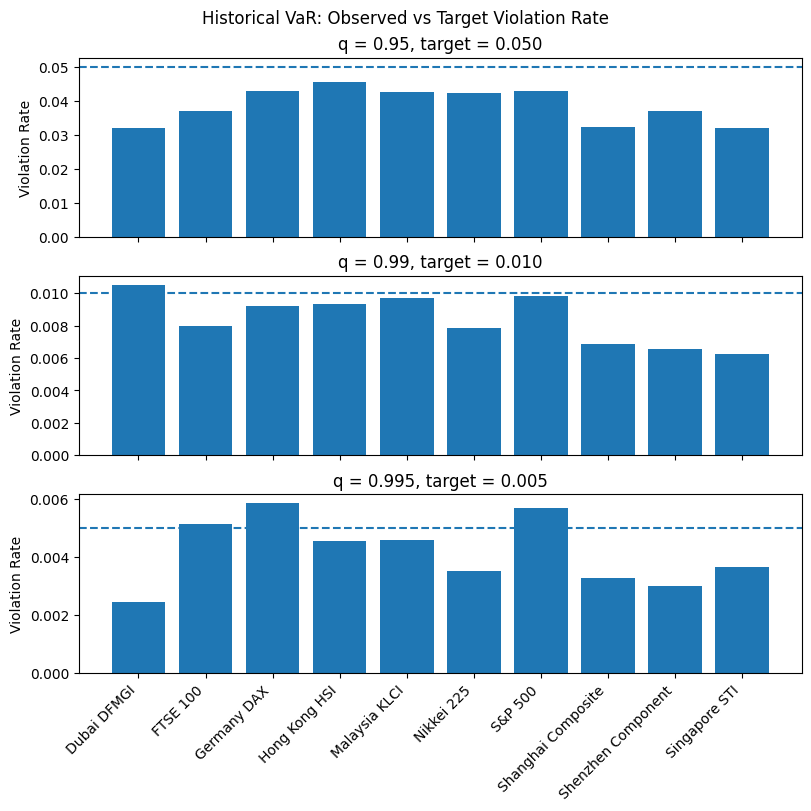

In [16]:
# ============================================================
# Plot 1: Observed vs Target Violation Rate, Stacked Panels
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


def plot_observed_vs_target_violation_rate_stacked(summary_df):
    """
    Plot observed violation rates against target violation rates
    for each VaR level, stacked vertically.

    X-axis labels are shown only on the bottom panel.
    """
    var_levels = sorted(summary_df["VaR Level"].unique())

    index_order = (
        summary_df[summary_df["VaR Level"] == var_levels[0]]
        .sort_values("Index")["Index"]
        .tolist()
    )

    fig, axes = plt.subplots(
        len(var_levels),
        1,
        figsize=(8, 8),
        sharex=True,
        constrained_layout=True,
    )

    if len(var_levels) == 1:
        axes = [axes]

    x = np.arange(len(index_order))

    for ax, q in zip(axes, var_levels):
        df_q = summary_df[summary_df["VaR Level"] == q].copy()
        df_q = df_q.set_index("Index").reindex(index_order).reset_index()

        target = 1 - q

        ax.bar(x, df_q["violation_rate"])
        ax.axhline(target, linestyle="--", linewidth=1.5)

        ax.set_ylabel("Violation Rate")
        ax.set_title(f"q = {q}, target = {target:.3f}")

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(index_order, rotation=45, ha="right")

    fig.suptitle("Historical VaR: Observed vs Target Violation Rate")
    plt.show()


plot_observed_vs_target_violation_rate_stacked(historical_var_summary_df)

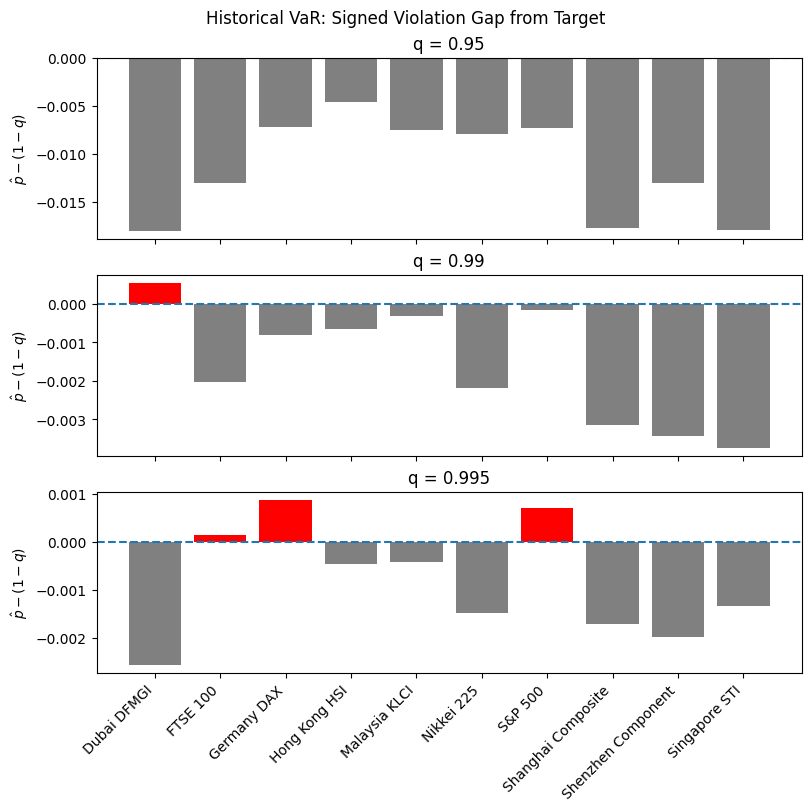

In [17]:
# ============================================================
# Plot 2: Signed Violation Gap from Target, Stacked Panels
# ============================================================

def plot_signed_violation_gap_stacked(summary_df):
    """
    Plot signed difference between observed and target violation rates:

        violation_rate - target_violation_rate

    Positive values mean too many violations, hence possible risk underestimation.
    Negative values mean too few violations, hence conservative VaR.
    """
    var_levels = sorted(summary_df["VaR Level"].unique())

    index_order = (
        summary_df[summary_df["VaR Level"] == var_levels[0]]
        .sort_values("Index")["Index"]
        .tolist()
    )

    fig, axes = plt.subplots(
        len(var_levels),
        1,
        figsize=(8, 8),
        sharex=True,
        constrained_layout=True,
    )

    if len(var_levels) == 1:
        axes = [axes]

    x = np.arange(len(index_order))

    for ax, q in zip(axes, var_levels):
        df_q = summary_df[summary_df["VaR Level"] == q].copy()
        df_q = df_q.set_index("Index").reindex(index_order).reset_index()

        signed_gap = df_q["violation_rate"] - df_q["target_violation_rate"]

        bar_colors = [
            "red" if value > 0 else "gray"
            for value in signed_gap
        ]

        ax.bar(x, signed_gap, color=bar_colors)
        ax.axhline(0, linestyle="--", linewidth=1.5)

        ax.set_ylabel(r"$\hat{p} - (1-q)$")
        ax.set_title(f"q = {q}")

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(index_order, rotation=45, ha="right")

    fig.suptitle("Historical VaR: Signed Violation Gap from Target")
    plt.show()


plot_signed_violation_gap_stacked(historical_var_summary_df)

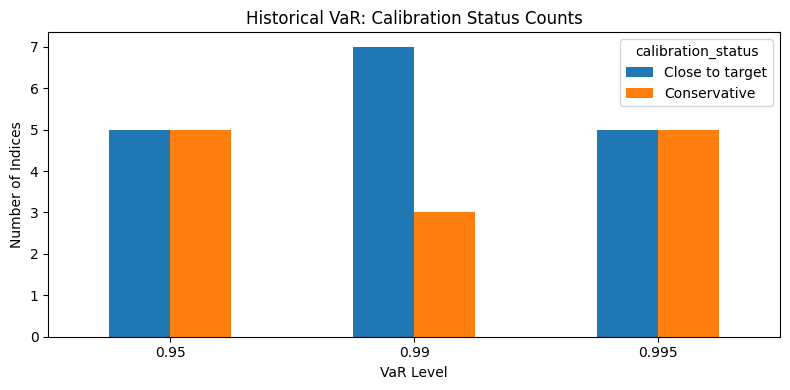

calibration_status,Close to target,Conservative
VaR Level,,
0.950,5,5
0.990,7,3
0.995,5,5


In [12]:
# ============================================================
# Plot 3: Calibration Status Counts
# ============================================================

def plot_calibration_status_counts(summary_df):
    """
    Plot the number of indices classified under each calibration status,
    grouped by VaR level.
    """
    count_table = (
        summary_df
        .groupby(["VaR Level", "calibration_status"])
        .size()
        .unstack(fill_value=0)
    )

    count_table.plot(kind="bar", figsize=(8, 4))

    plt.xlabel("VaR Level")
    plt.ylabel("Number of Indices")
    plt.title("Historical VaR: Calibration Status Counts")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return count_table


calibration_count_table = plot_calibration_status_counts(historical_var_summary_df)
calibration_count_table

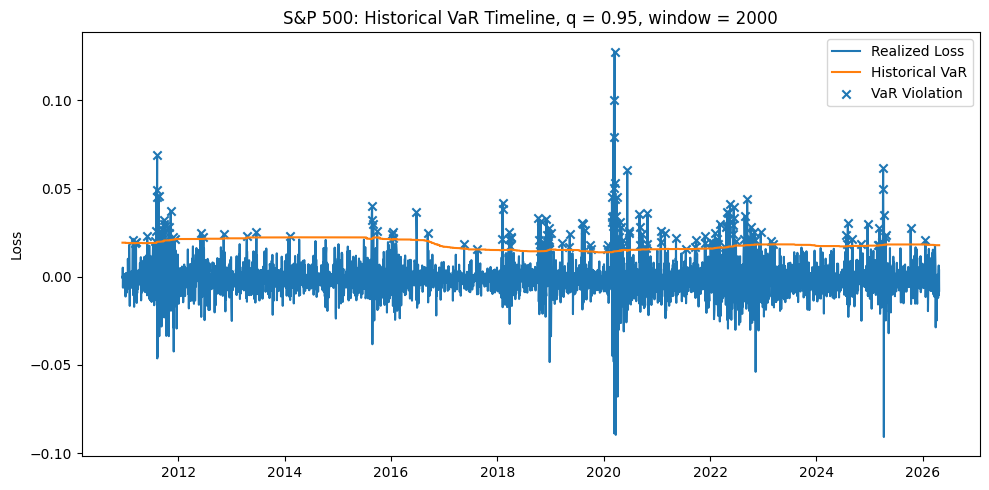

In [29]:
# ============================================================
# Plot 4: Example VaR Violation Timeline
# ============================================================

index_name = "S&P 500" # "Malaysia KLCI" etc.
q = 0.95
window_length = 2000

def plot_var_timeline(
    forecasts_dict,
    index_name=index_name,
    window_length=2000,
    q=q,
    last_n=None,
):
    """
    Plot realized losses and Historical VaR forecasts for one index and VaR level.
    """
    key = (index_name, window_length, q)

    if key not in forecasts_dict:
        raise KeyError(f"No forecast data found for key: {key}")

    df = forecasts_dict[key].copy()

    if last_n is not None:
        df = df.tail(last_n)

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["realized_loss"], label="Realized Loss")
    plt.plot(df.index, df["historical_var"], label="Historical VaR")

    violation_df = df[df["violation"] == 1]
    plt.scatter(
        violation_df.index,
        violation_df["realized_loss"],
        marker="x",
        label="VaR Violation",
    )

    plt.ylabel("Loss")
    plt.title(f"{index_name}: Historical VaR Timeline, q = {q}, window = {window_length}")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_var_timeline(
    historical_var_forecasts_dict,
    index_name=index_name,
    window_length=WINDOW_LENGTH,
    q=q,
    last_n=None,
)

## 2. Normal VaR

We next introduce Normal VaR. Unlike Historical VaR, which takes the empirical quantile of observed losses directly, Normal VaR assumes that portfolio losses are approximately normally distributed over the rolling estimation window.

Let the rolling loss sample at time $t$ be

$$
L_{t-\ell},L_{t-\ell+1},\ldots,L_{t-1}.
$$

We estimate the rolling mean and standard deviation by

$$
\hat{\mu}_{t,\ell}
=
\frac{1}{\ell}
\sum_{j=t-\ell}^{t-1} L_j,
$$

and

$$
\hat{\sigma}_{t,\ell}
=
\sqrt{
\frac{1}{\ell-1}
\sum_{j=t-\ell}^{t-1}
\left(L_j-\hat{\mu}_{t,\ell}\right)^2
}.
$$

For confidence level $q$, the one-step-ahead Normal VaR forecast is

$$
\widehat{\operatorname{VaR}}^{\mathrm{Normal}}_{q,t}
=
\hat{\mu}_{t,\ell}
+
\hat{\sigma}_{t,\ell}\Phi^{-1}(q),
$$

where $\Phi^{-1}(q)$ is the $q$-quantile of the standard normal distribution.

Thus, Normal VaR replaces the empirical quantile used in Historical VaR with a model-implied quantile. It is still a lightweight baseline, because it only estimates two quantities from the rolling window: the mean and standard deviation.

The advantage of Normal VaR is that it is simple, fast, and smooth. Its weakness is that financial losses are often not normally distributed. If the empirical loss distribution is skewed, fat-tailed, or crisis-sensitive, the normal assumption may underestimate tail risk, especially at high confidence levels such as $99\%$ or $99.5\%$.

In this notebook, Normal VaR is treated as a parametric baseline rather than as a claim that losses are truly normal. We use the same rolling window length and VaR confidence levels as in the Historical VaR section so that the two baseline methods can be compared directly.

In [30]:
# ============================================================
# Normal VaR Forecast Function
# ============================================================

from scipy.stats import norm

def normal_var_forecasts(loss_series, q, window_length):
    """
    Rolling one-step-ahead Normal VaR forecasts.

    Parameters
    ----------
    loss_series : pd.Series
        Loss series where large positive values correspond to large losses.
    q : float
        VaR confidence level.
    window_length : int
        Rolling lookback window.

    Returns
    -------
    realized_losses : pd.Series
        Realized losses over the out-of-sample forecast period.
    var_forecasts : pd.Series
        Rolling one-step-ahead Normal VaR forecasts.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]

    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    z_q = norm.ppf(q)

    for t in forecast_index:
        t_pos = loss_series.index.get_loc(t)

        window_losses = loss_series.iloc[t_pos - window_length:t_pos]

        mu_hat = window_losses.mean()
        sigma_hat = window_losses.std(ddof=1)

        var_forecasts.loc[t] = mu_hat + sigma_hat * z_q

    return realized_losses, var_forecasts

In [31]:
# ============================================================
# Run Normal VaR Across All Indices
# ============================================================

normal_var_results = []
normal_var_forecasts_dict = {}

for index_name in losses.columns:
    print(f"Running Normal VaR for {index_name}...")

    loss_series = losses[index_name].dropna()

    for q in VAR_LEVELS:
        realized_losses, var_forecasts = normal_var_forecasts(
            loss_series=loss_series,
            q=q,
            window_length=WINDOW_LENGTH,
        )

        metrics = compute_basic_var_metrics(
            realized_losses=realized_losses,
            var_forecasts=var_forecasts,
            q=q,
        )

        normal_var_results.append({
            "Index": index_name,
            "Window Length": WINDOW_LENGTH,
            "VaR Level": q,
            "Model": "Normal VaR",
            **metrics,
        })

        normal_var_forecasts_dict[(index_name, WINDOW_LENGTH, q)] = pd.DataFrame({
            "realized_loss": realized_losses,
            "normal_var": var_forecasts,
            "violation": (realized_losses > var_forecasts).astype(int),
        })

normal_var_results_df = pd.DataFrame(normal_var_results)

normal_var_results_df

Running Normal VaR for S&P 500...
Running Normal VaR for Malaysia KLCI...
Running Normal VaR for FTSE 100...
Running Normal VaR for Dubai DFMGI...
Running Normal VaR for Singapore STI...
Running Normal VaR for Hong Kong HSI...
Running Normal VaR for Shanghai Composite...
Running Normal VaR for Shenzhen Component...
Running Normal VaR for Nikkei 225...
Running Normal VaR for Germany DAX...


,Index,Window Length,VaR Level,Model,num_forecasts,num_violations,violation_rate,target_violation_rate,abs_deviation
0,S&P 500,2000,0.950,Normal VaR,3864,145,0.037526,0.050,0.012474
1,S&P 500,2000,0.990,Normal VaR,3864,68,0.017598,0.010,0.007598
2,S&P 500,2000,0.995,Normal VaR,3864,56,0.014493,0.005,0.009493
3,Malaysia KLCI,2000,0.950,Normal VaR,3717,146,0.039279,0.050,0.010721
4,Malaysia KLCI,2000,0.990,Normal VaR,3717,54,0.014528,0.010,0.004528
5,Malaysia KLCI,2000,0.995,Normal VaR,3717,46,0.012376,0.005,0.007376
6,FTSE 100,2000,0.950,Normal VaR,3888,121,0.031121,0.050,0.018879
7,FTSE 100,2000,0.990,Normal VaR,3888,57,0.014660,0.010,0.004660
8,FTSE 100,2000,0.995,Normal VaR,3888,42,0.010802,0.005,0.005802
9,Dubai DFMGI,2000,0.950,Normal VaR,2467,63,0.025537,0.050,0.024463


In [32]:
# ============================================================
# Summarize Normal VaR Calibration
# ============================================================

normal_var_summary_df = normal_var_results_df.copy()

normal_var_summary_df["calibration_status"] = normal_var_summary_df.apply(
    classify_var_calibration,
    axis=1,
)

normal_var_summary_df["violation_gap"] = (
    normal_var_summary_df["violation_rate"]
    - normal_var_summary_df["target_violation_rate"]
)

normal_var_summary_df["relative_violation_gap"] = (
    normal_var_summary_df["violation_gap"]
    / normal_var_summary_df["target_violation_rate"]
)

normal_var_summary_df

,Index,Window Length,VaR Level,Model,num_forecasts,num_violations,violation_rate,target_violation_rate,abs_deviation,calibration_status,violation_gap,relative_violation_gap
0,S&P 500,2000,0.950,Normal VaR,3864,145,0.037526,0.050,0.012474,Close to target,-0.012474,-0.249482
1,S&P 500,2000,0.990,Normal VaR,3864,68,0.017598,0.010,0.007598,Underestimates risk,0.007598,0.759834
2,S&P 500,2000,0.995,Normal VaR,3864,56,0.014493,0.005,0.009493,Underestimates risk,0.009493,1.898551
3,Malaysia KLCI,2000,0.950,Normal VaR,3717,146,0.039279,0.050,0.010721,Close to target,-0.010721,-0.214420
4,Malaysia KLCI,2000,0.990,Normal VaR,3717,54,0.014528,0.010,0.004528,Underestimates risk,0.004528,0.452785
5,Malaysia KLCI,2000,0.995,Normal VaR,3717,46,0.012376,0.005,0.007376,Underestimates risk,0.007376,1.475114
6,FTSE 100,2000,0.950,Normal VaR,3888,121,0.031121,0.050,0.018879,Conservative,-0.018879,-0.377572
7,FTSE 100,2000,0.990,Normal VaR,3888,57,0.014660,0.010,0.004660,Underestimates risk,0.004660,0.466049
8,FTSE 100,2000,0.995,Normal VaR,3888,42,0.010802,0.005,0.005802,Underestimates risk,0.005802,1.160494
9,Dubai DFMGI,2000,0.950,Normal VaR,2467,63,0.025537,0.050,0.024463,Conservative,-0.024463,-0.489258


In [33]:
# ============================================================
# Calibration Status Counts by VaR Level
# ============================================================

normal_calibration_count_table = (
    normal_var_summary_df
    .groupby(["VaR Level", "calibration_status"])
    .size()
    .unstack(fill_value=0)
)

normal_calibration_count_table

calibration_status,Close to target,Conservative,Underestimates risk
VaR Level,,,
0.950,5,5,0
0.990,2,0,8
0.995,0,0,10


In [34]:
# ============================================================
# Save Normal VaR Results
# ============================================================

normal_var_results_path = os.path.join(
    RESULTS_DIR,
    f"01_normal_var_results_window_{WINDOW_LENGTH}.csv"
)

normal_var_summary_path = os.path.join(
    RESULTS_DIR,
    f"01_normal_var_summary_window_{WINDOW_LENGTH}.csv"
)

normal_var_results_df.to_csv(normal_var_results_path, index=False)
normal_var_summary_df.to_csv(normal_var_summary_path, index=False)

print(f"Saved Normal VaR results to: {normal_var_results_path}")
print(f"Saved Normal VaR summary to: {normal_var_summary_path}")

Saved Normal VaR results to: results/01_normal_var_results_window_2000.csv
Saved Normal VaR summary to: results/01_normal_var_summary_window_2000.csv


## Normal VaR Results with a 2000-Day Window

The Normal VaR results show the usual limitation of imposing a Gaussian loss distribution. At the 95% VaR level, the model behaves reasonably: 5 out of 10 indices are close to the target violation rate, while 5 are conservative. Thus, at a moderate confidence level, the normal approximation is not entirely unreasonable.

The picture changes at higher confidence levels. At the 99% VaR level, only 2 out of 10 indices are close to the target violation rate, while 8 underestimate risk. At the 99.5% VaR level, all 10 indices underestimate risk. This means realized losses exceed the Normal VaR threshold more often than they should.

This is consistent with the common empirical fact that equity-index losses are heavier-tailed than the normal distribution. The normal model may describe the central part of the loss distribution reasonably well, but it is too thin-tailed for extreme-loss estimation. See the second plot below.

This result also contrasts with the Historical VaR baseline. Under the same 2000-day rolling window, Historical VaR was generally cautious: no index was classified as underestimating risk under the chosen tolerance rule. Normal VaR, however, becomes increasingly optimistic as the confidence level rises. In this sense, Historical VaR is more conservative and more directly tied to observed tail losses, while Normal VaR is smoother but more vulnerable to tail underestimation.

Overall, Normal VaR is useful as a simple parametric benchmark, but these results suggest that it should not be trusted on its own for high-confidence tail-risk estimation.

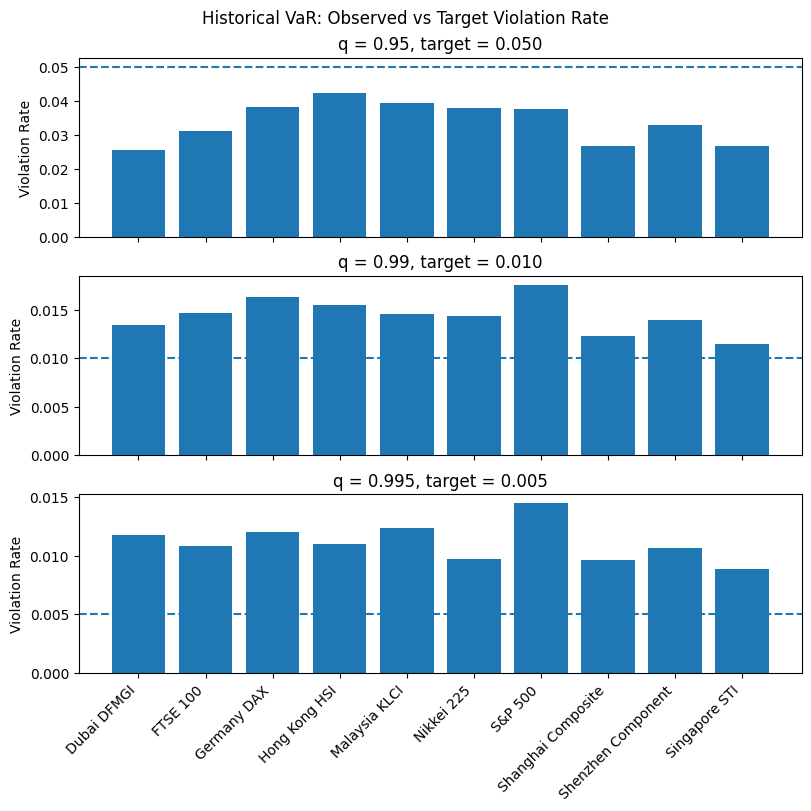

In [35]:
# ============================================================
# Plot 1: Observed vs Target Violation Rate for Normal VaR
# ============================================================

plot_observed_vs_target_violation_rate_stacked(normal_var_summary_df)

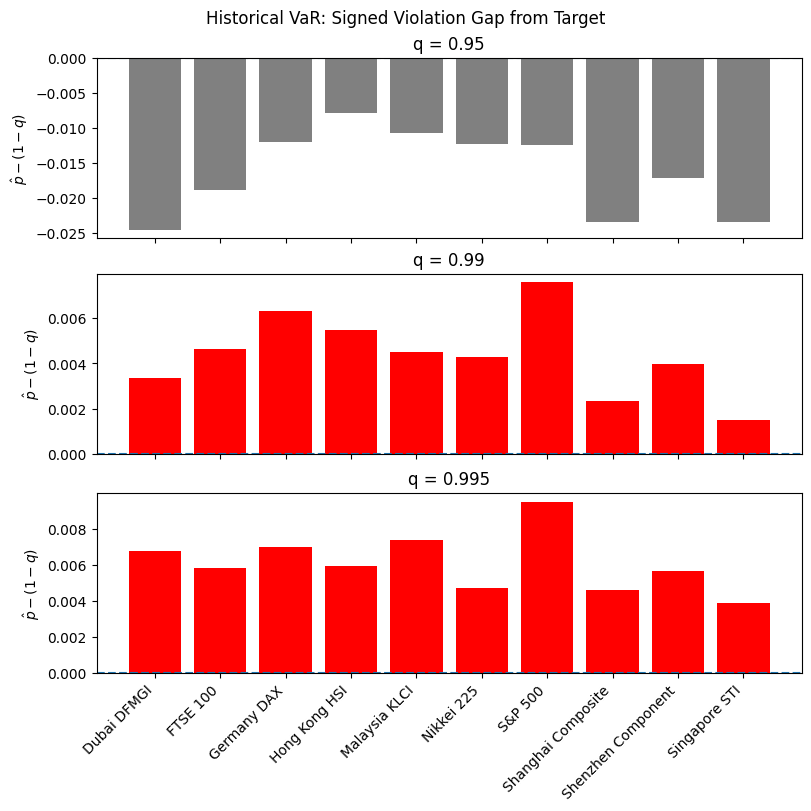

In [36]:
# ============================================================
# Plot 2: Signed Violation Gap from Target for Normal VaR
# ============================================================

plot_signed_violation_gap_stacked(normal_var_summary_df)

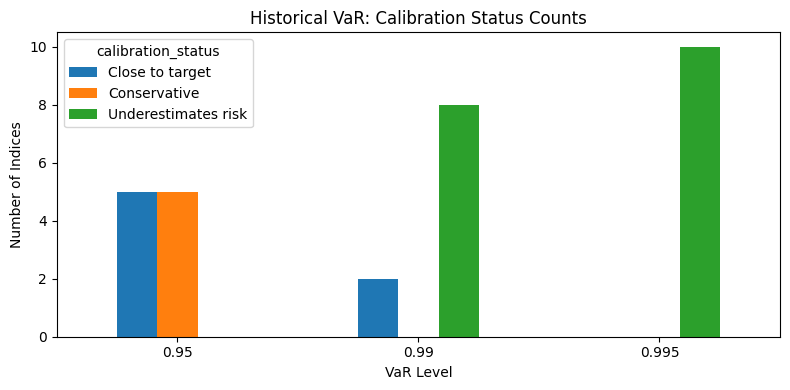

calibration_status,Close to target,Conservative,Underestimates risk
VaR Level,,,
0.950,5,5,0
0.990,2,0,8
0.995,0,0,10


In [37]:
# ============================================================
# Plot 3: Calibration Status Counts for Normal VaR
# ============================================================

normal_calibration_count_table = plot_calibration_status_counts(normal_var_summary_df)
normal_calibration_count_table

In [40]:
# ============================================================
# Plot 4: Generic VaR Timeline Plot
# ============================================================

def plot_generic_var_timeline(
    forecasts_dict,
    index_name,
    window_length,
    q,
    var_column,
    model_label,
    last_n=None,
):
    """
    Plot realized losses and VaR forecasts for one index and one model.
    """
    key = (index_name, window_length, q)

    if key not in forecasts_dict:
        raise KeyError(f"No forecast data found for key: {key}")

    df = forecasts_dict[key].copy()

    if last_n is not None:
        df = df.tail(last_n)

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["realized_loss"], label="Realized Loss")
    plt.plot(df.index, df[var_column], label=model_label)

    violation_df = df[df["violation"] == 1]
    plt.scatter(
        violation_df.index,
        violation_df["realized_loss"],
        marker="x",
        label="VaR Violation",
    )

    plt.ylabel("Loss")
    plt.title(f"{index_name}: {model_label} Timeline, q = {q}, window = {window_length}")
    plt.legend()
    plt.tight_layout()
    plt.show()

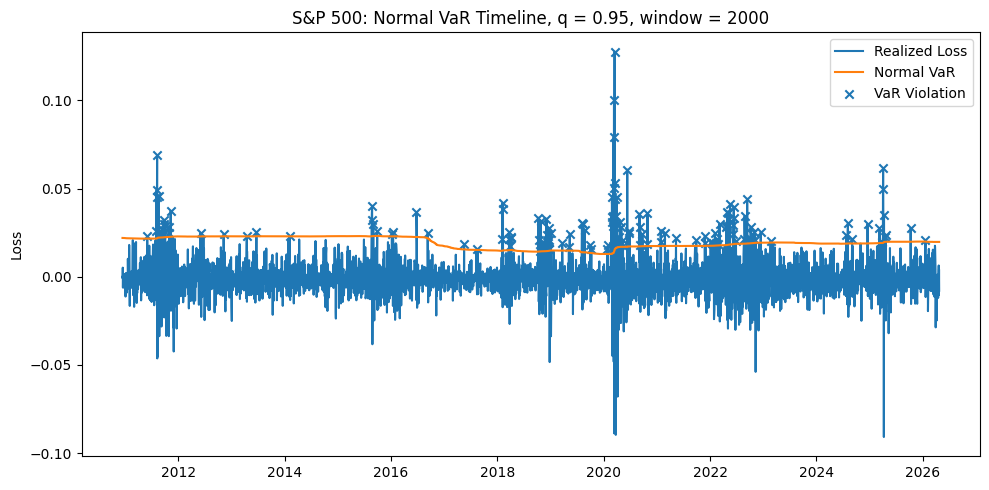

In [42]:
# ============================================================
# Plot 4: Normal VaR Timeline
# ============================================================

plot_generic_var_timeline(
    forecasts_dict=normal_var_forecasts_dict,
    index_name="S&P 500",
    window_length=WINDOW_LENGTH,
    q=0.95,
    var_column="normal_var",
    model_label="Normal VaR",
    last_n=None,   # or set, e.g. 1000
)

In [43]:
# ============================================================
# Plot 5: Historical VaR vs Normal VaR Comparison
# ============================================================

def plot_var_comparison_timeline(
    historical_dict,
    normal_dict,
    index_name,
    window_length,
    q,
    last_n=None,
):
    """
    Plot realized losses together with Historical VaR and Normal VaR
    for direct comparison.
    """
    key = (index_name, window_length, q)

    if key not in historical_dict:
        raise KeyError(f"No Historical VaR data found for key: {key}")
    if key not in normal_dict:
        raise KeyError(f"No Normal VaR data found for key: {key}")

    hist_df = historical_dict[key].copy()
    norm_df = normal_dict[key].copy()

    df = pd.concat(
        [
            hist_df[["realized_loss", "historical_var", "violation"]].rename(
                columns={"violation": "historical_violation"}
            ),
            norm_df[["normal_var", "violation"]].rename(
                columns={"violation": "normal_violation"}
            ),
        ],
        axis=1,
    )

    if last_n is not None:
        df = df.tail(last_n)

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["realized_loss"], label="Realized Loss")
    plt.plot(df.index, df["historical_var"], label="Historical VaR")
    plt.plot(df.index, df["normal_var"], label="Normal VaR")

    hist_viol = df[df["historical_violation"] == 1]
    norm_viol = df[df["normal_violation"] == 1]

    plt.scatter(
        hist_viol.index,
        hist_viol["realized_loss"],
        marker="o",
        label="Historical VaR Violation",
    )
    plt.scatter(
        norm_viol.index,
        norm_viol["realized_loss"],
        marker="x",
        label="Normal VaR Violation",
    )

    plt.ylabel("Loss")
    plt.title(f"{index_name}: Historical VaR vs Normal VaR, q = {q}, window = {window_length}")
    plt.legend()
    plt.tight_layout()
    plt.show()

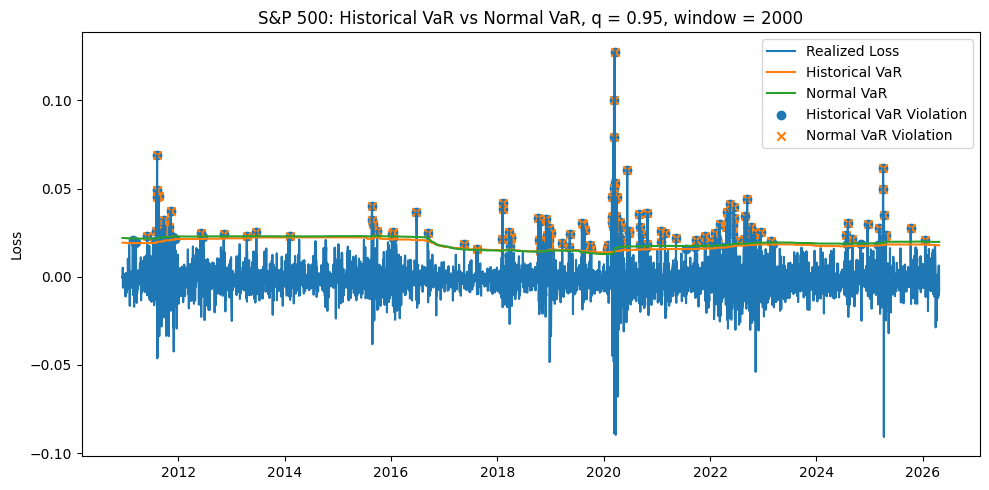

In [46]:
# ============================================================
# Historical VaR vs Normal VaR Comparison
# ============================================================

plot_var_comparison_timeline(
    historical_dict=historical_var_forecasts_dict,
    normal_dict=normal_var_forecasts_dict,
    index_name="S&P 500",
    window_length=WINDOW_LENGTH,
    q=0.95,
    last_n=None,   # or set, e.g. 1000
)

## 3. Student-$t$ VaR

We next introduce Student-$t$ VaR. This is still a distribution-based VaR method, but it relaxes the thin-tail assumption of Normal VaR. Instead of assuming that losses are normally distributed, we assume that losses are approximately described by a Student-$t$ distribution.

The motivation is simple: financial losses often have heavier tails than the normal distribution. A Student-$t$ distribution can reflect heavier tails through its degrees-of-freedom parameter $\nu$. Smaller values of $\nu$ imply heavier tails, while larger values of $\nu$ make the Student-$t$ distribution closer to the normal distribution.

In a full rolling implementation, one could estimate $\nu$, the location, and the scale parameter separately inside every rolling window. However, this would require thousands of rolling distribution fits across all indices. Since this notebook is intended to demonstrate baseline VaR methods rather than build a full production-scale VaR engine, we use a simpler diagnostic approach.

For a Student-$t$ distribution with $\nu>4$, the excess kurtosis is

$$
\kappa
=
\frac{6}{\nu-4}.
$$

Solving this equation for \(\nu\) gives the moment-based estimate

$$
\hat{\nu}
=
4+\frac{6}{\hat{\kappa}},
$$

where $\hat{\kappa}$ is the sample excess kurtosis of the observed loss series.

We use this relation as a practical diagnostic for the degrees of freedom. Specifically, for each index, we estimate $\nu$ from the full sample and from three equal subsamples: the first third, middle third, and final third. This lets us check whether the implied tail thickness is reasonably stable across time.

This is not a full maximum-likelihood estimation of a Student-$t$ model. It is a lightweight moment-based diagnostic used to choose a reasonable fixed degrees-of-freedom parameter for the Student-$t$ VaR baseline.

In [47]:
# ============================================================
# Student-t Degrees of Freedom Diagnostic via Excess Kurtosis
# ============================================================

from scipy.stats import kurtosis
import numpy as np
import pandas as pd


def estimate_t_dof_from_excess_kurtosis(x, min_excess_kurtosis=1e-8):
    """
    Estimate Student-t degrees of freedom using the moment relation:

        excess kurtosis = 6 / (nu - 4)

    so that:

        nu = 4 + 6 / excess_kurtosis

    This only makes sense when excess kurtosis is positive.
    """
    x = pd.Series(x).dropna().astype(float)

    if len(x) < 10:
        return np.nan

    excess_kurt = kurtosis(x, fisher=True, bias=False)

    if not np.isfinite(excess_kurt) or excess_kurt <= min_excess_kurtosis:
        return np.nan

    nu_hat = 4 + 6 / excess_kurt

    return nu_hat


def split_series_into_thirds(x):
    """
    Split a series into first, middle, and final thirds.
    """
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    first = x.iloc[: n // 3]
    middle = x.iloc[n // 3 : 2 * n // 3]
    final = x.iloc[2 * n // 3 :]

    return {
        "Full Sample": x,
        "First Third": first,
        "Middle Third": middle,
        "Final Third": final,
    }


# ============================================================
# Compute Moment-Based Student-t DoF Diagnostics
# ============================================================

t_dof_diagnostics = []

for index_name in losses.columns:
    loss_series = losses[index_name].dropna()

    segments = split_series_into_thirds(loss_series)

    for segment_name, segment_values in segments.items():
        excess_kurt = kurtosis(segment_values, fisher=True, bias=False)
        nu_hat = estimate_t_dof_from_excess_kurtosis(segment_values)

        t_dof_diagnostics.append({
            "Index": index_name,
            "Segment": segment_name,
            "Obs.": len(segment_values),
            "Excess Kurtosis": excess_kurt,
            "Estimated DoF": nu_hat,
        })

t_dof_diagnostics_df = pd.DataFrame(t_dof_diagnostics)

t_dof_diagnostics_df

,Index,Segment,Obs.,Excess Kurtosis,Estimated DoF
0,S&P 500,Full Sample,5864,13.149779,4.456281
1,S&P 500,First Third,1954,10.744050,4.558449
2,S&P 500,Middle Third,1955,5.299642,5.132152
3,S&P 500,Final Third,1955,15.009680,4.399742
4,Malaysia KLCI,Full Sample,5717,11.637783,4.515562
5,Malaysia KLCI,First Third,1905,13.147665,4.456355
6,Malaysia KLCI,Middle Third,1906,3.080523,5.947721
7,Malaysia KLCI,Final Third,1906,8.942365,4.670963
8,FTSE 100,Full Sample,5888,10.395133,4.577193
9,FTSE 100,First Third,1962,8.651393,4.693530


In [48]:
# ============================================================
# Pivot Table: Estimated DoF by Index and Segment
# ============================================================

t_dof_pivot = (
    t_dof_diagnostics_df
    .pivot(index="Index", columns="Segment", values="Estimated DoF")
    .reindex(columns=["Full Sample", "First Third", "Middle Third", "Final Third"])
)

t_dof_pivot

Segment,Full Sample,First Third,Middle Third,Final Third
Index,,,,
Dubai DFMGI,4.537345,4.962356,4.639485,4.205830
FTSE 100,4.577193,4.693530,6.408923,4.362427
Germany DAX,4.797722,4.909789,6.148682,4.463121
Hong Kong HSI,4.682396,4.630783,6.231742,4.862200
Malaysia KLCI,4.515562,4.456355,5.947721,4.670963
Nikkei 225,4.726994,4.743064,4.972837,4.644223
S&P 500,4.456281,4.558449,5.132152,4.399742
Shanghai Composite,5.080932,5.973116,4.878227,4.788996
Shenzhen Component,5.553967,6.437449,5.488605,5.028564


In [49]:
# ============================================================
# DoF Stability Summary Across Thirds
# ============================================================

third_cols = ["First Third", "Middle Third", "Final Third"]

t_dof_stability = t_dof_pivot.copy()

t_dof_stability["Mean DoF Across Thirds"] = t_dof_stability[third_cols].mean(axis=1)
t_dof_stability["Std DoF Across Thirds"] = t_dof_stability[third_cols].std(axis=1)
t_dof_stability["Min DoF Across Thirds"] = t_dof_stability[third_cols].min(axis=1)
t_dof_stability["Max DoF Across Thirds"] = t_dof_stability[third_cols].max(axis=1)
t_dof_stability["Range DoF Across Thirds"] = (
    t_dof_stability["Max DoF Across Thirds"]
    - t_dof_stability["Min DoF Across Thirds"]
)

t_dof_stability

Segment,Full Sample,First Third,Middle Third,Final Third,Mean DoF Across Thirds,Std DoF Across Thirds,Min DoF Across Thirds,Max DoF Across Thirds,Range DoF Across Thirds
Index,,,,,,,,,
Dubai DFMGI,4.537345,4.962356,4.639485,4.205830,4.602557,0.379612,4.205830,4.962356,0.756526
FTSE 100,4.577193,4.693530,6.408923,4.362427,5.154960,1.098510,4.362427,6.408923,2.046496
Germany DAX,4.797722,4.909789,6.148682,4.463121,5.173864,0.873259,4.463121,6.148682,1.685562
Hong Kong HSI,4.682396,4.630783,6.231742,4.862200,5.241575,0.865281,4.630783,6.231742,1.600959
Malaysia KLCI,4.515562,4.456355,5.947721,4.670963,5.025013,0.806261,4.456355,5.947721,1.491366
Nikkei 225,4.726994,4.743064,4.972837,4.644223,4.786708,0.168598,4.644223,4.972837,0.328614
S&P 500,4.456281,4.558449,5.132152,4.399742,4.696781,0.385302,4.399742,5.132152,0.732410
Shanghai Composite,5.080932,5.973116,4.878227,4.788996,5.213446,0.659405,4.788996,5.973116,1.184120
Shenzhen Component,5.553967,6.437449,5.488605,5.028564,5.651539,0.718436,5.028564,6.437449,1.408885


In [50]:
# ============================================================
# Save Student-t DoF Diagnostics
# ============================================================

t_dof_diagnostics_path = os.path.join(
    RESULTS_DIR,
    "01_student_t_dof_diagnostics.csv"
)

t_dof_pivot_path = os.path.join(
    RESULTS_DIR,
    "01_student_t_dof_pivot.csv"
)

t_dof_stability_path = os.path.join(
    RESULTS_DIR,
    "01_student_t_dof_stability.csv"
)

t_dof_diagnostics_df.to_csv(t_dof_diagnostics_path, index=False)
t_dof_pivot.to_csv(t_dof_pivot_path)
t_dof_stability.to_csv(t_dof_stability_path)

print(f"Saved DoF diagnostics to: {t_dof_diagnostics_path}")
print(f"Saved DoF pivot table to: {t_dof_pivot_path}")
print(f"Saved DoF stability table to: {t_dof_stability_path}")

Saved DoF diagnostics to: results/01_student_t_dof_diagnostics.csv
Saved DoF pivot table to: results/01_student_t_dof_pivot.csv
Saved DoF stability table to: results/01_student_t_dof_stability.csv


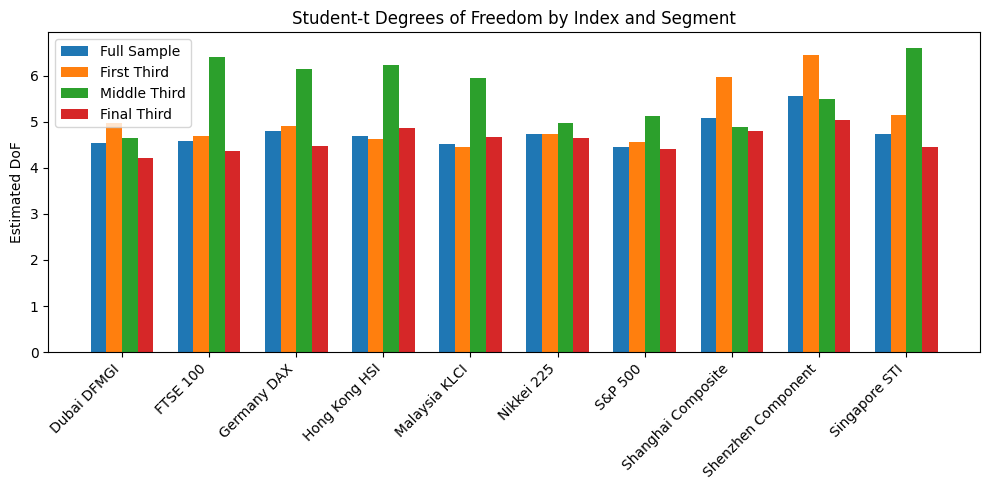

In [51]:
# ============================================================
# Plot: Estimated Student-t DoF by Index and Segment
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_t_dof_grouped_bars(t_dof_pivot):
    """
    Grouped bar chart of estimated Student-t degrees of freedom
    across indices and sample segments.
    """
    plot_df = t_dof_pivot.copy()

    segment_order = ["Full Sample", "First Third", "Middle Third", "Final Third"]
    plot_df = plot_df[segment_order]

    indices = plot_df.index.tolist()
    x = np.arange(len(indices))
    width = 0.18

    plt.figure(figsize=(10, 5))

    for i, segment in enumerate(segment_order):
        plt.bar(
            x + (i - 1.5) * width,
            plot_df[segment].values,
            width=width,
            label=segment,
        )

    plt.xticks(x, indices, rotation=45, ha="right")
    plt.ylabel("Estimated DoF")
    plt.title("Student-t Degrees of Freedom by Index and Segment")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_t_dof_grouped_bars(t_dof_pivot)

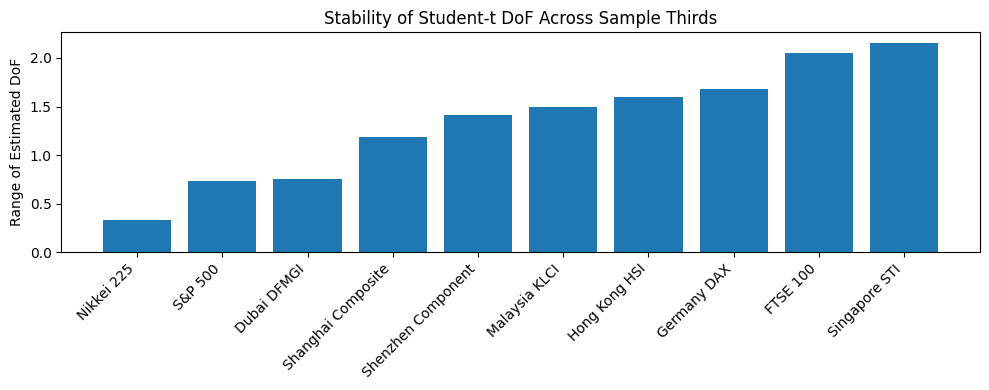

In [52]:
# ============================================================
# Plot: DoF Stability Range Across Thirds
# ============================================================

def plot_t_dof_stability_range(t_dof_stability):
    """
    Bar chart of the DoF range across the three thirds.
    Smaller range means greater stability.
    """
    plot_df = t_dof_stability.sort_values("Range DoF Across Thirds").copy()

    x = np.arange(len(plot_df))

    plt.figure(figsize=(10, 4))
    plt.bar(x, plot_df["Range DoF Across Thirds"].values)

    plt.xticks(x, plot_df.index, rotation=45, ha="right")
    plt.ylabel("Range of Estimated DoF")
    plt.title("Stability of Student-t DoF Across Sample Thirds")
    plt.tight_layout()
    plt.show()


plot_t_dof_stability_range(t_dof_stability)

## Choosing the Degrees of Freedom

The grouped bar chart above shows the moment-based Student-$t$ degrees-of-freedom estimates across indices and sample segments. The estimates are not identical, but they are reasonably concentrated. Most values lie roughly between 4.3 and 6.5.

This suggests that the equity-index loss series are consistently heavy-tailed. A normal distribution would correspond to the limiting case $\nu \to \infty$, which is clearly not the behavior suggested by the excess-kurtosis diagnostic.

The final third of the sample often has a lower estimated $\nu$, indicating heavier tails in the more recent period. This is plausible because the later sample includes events such as COVID-era market stress, inflation shocks, and rate-hike uncertainty. The middle third often has a higher $\nu$, suggesting a relatively less heavy-tailed period.

Based on this diagnostic, we choose

$$
\nu = 5
$$

as a pragmatic fixed degrees-of-freedom parameter for the Student-$t$ VaR baseline. This value is not claimed to be optimal. It is a reasonable compromise suggested by the moment-based estimates: heavy-tailed enough to improve on Normal VaR, but simple enough to keep the model transparent and computationally light.

With $\nu$ fixed at 5, the rolling Student-$t$ VaR model only needs to estimate the rolling mean and standard deviation of losses, just as Normal VaR does. The difference is that the normal quantile is replaced by the Student-$t$ quantile with 5 degrees of freedom.

In [53]:
# ============================================================
# Student-t VaR Forecast Function
# ============================================================

from scipy.stats import t

STUDENT_T_DOF = 5

def student_t_var_forecasts(loss_series, q, window_length, dof=5):
    """
    Rolling one-step-ahead Student-t VaR forecasts with fixed degrees of freedom.

    Parameters
    ----------
    loss_series : pd.Series
        Loss series where large positive values correspond to large losses.
    q : float
        VaR confidence level.
    window_length : int
        Rolling lookback window.
    dof : float
        Fixed Student-t degrees of freedom.

    Returns
    -------
    realized_losses : pd.Series
        Realized losses over the out-of-sample forecast period.
    var_forecasts : pd.Series
        Rolling one-step-ahead Student-t VaR forecasts.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]

    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    # scipy's Student-t has variance dof / (dof - 2), so standardize it to variance 1.
    t_q = t.ppf(q, df=dof) / np.sqrt(dof / (dof - 2))

    for date in forecast_index:
        date_pos = loss_series.index.get_loc(date)

        window_losses = loss_series.iloc[date_pos - window_length:date_pos]

        mu_hat = window_losses.mean()
        sigma_hat = window_losses.std(ddof=1)

        var_forecasts.loc[date] = mu_hat + sigma_hat * t_q

    return realized_losses, var_forecasts

In [54]:
# ============================================================
# Run Student-t VaR Across All Indices
# ============================================================

student_t_var_results = []
student_t_var_forecasts_dict = {}

for index_name in losses.columns:
    print(f"Running Student-t VaR for {index_name}...")

    loss_series = losses[index_name].dropna()

    for q in VAR_LEVELS:
        realized_losses, var_forecasts = student_t_var_forecasts(
            loss_series=loss_series,
            q=q,
            window_length=WINDOW_LENGTH,
            dof=STUDENT_T_DOF,
        )

        metrics = compute_basic_var_metrics(
            realized_losses=realized_losses,
            var_forecasts=var_forecasts,
            q=q,
        )

        student_t_var_results.append({
            "Index": index_name,
            "Window Length": WINDOW_LENGTH,
            "VaR Level": q,
            "DoF": STUDENT_T_DOF,
            "Model": f"Student-t VaR, DoF={STUDENT_T_DOF}",
            **metrics,
        })

        student_t_var_forecasts_dict[(index_name, WINDOW_LENGTH, q)] = pd.DataFrame({
            "realized_loss": realized_losses,
            "student_t_var": var_forecasts,
            "violation": (realized_losses > var_forecasts).astype(int),
        })

student_t_var_results_df = pd.DataFrame(student_t_var_results)

student_t_var_results_df

Running Student-t VaR for S&P 500...
Running Student-t VaR for Malaysia KLCI...
Running Student-t VaR for FTSE 100...
Running Student-t VaR for Dubai DFMGI...
Running Student-t VaR for Singapore STI...
Running Student-t VaR for Hong Kong HSI...
Running Student-t VaR for Shanghai Composite...
Running Student-t VaR for Shenzhen Component...
Running Student-t VaR for Nikkei 225...
Running Student-t VaR for Germany DAX...


,Index,Window Length,VaR Level,DoF,Model,num_forecasts,num_violations,violation_rate,target_violation_rate,abs_deviation
0,S&P 500,2000,0.950,5,"Student-t VaR, DoF=5",3864,161,0.041667,0.050,0.008333
1,S&P 500,2000,0.990,5,"Student-t VaR, DoF=5",3864,54,0.013975,0.010,0.003975
2,S&P 500,2000,0.995,5,"Student-t VaR, DoF=5",3864,34,0.008799,0.005,0.003799
3,Malaysia KLCI,2000,0.950,5,"Student-t VaR, DoF=5",3717,166,0.044660,0.050,0.005340
4,Malaysia KLCI,2000,0.990,5,"Student-t VaR, DoF=5",3717,45,0.012107,0.010,0.002107
5,Malaysia KLCI,2000,0.995,5,"Student-t VaR, DoF=5",3717,23,0.006188,0.005,0.001188
6,FTSE 100,2000,0.950,5,"Student-t VaR, DoF=5",3888,138,0.035494,0.050,0.014506
7,FTSE 100,2000,0.990,5,"Student-t VaR, DoF=5",3888,41,0.010545,0.010,0.000545
8,FTSE 100,2000,0.995,5,"Student-t VaR, DoF=5",3888,27,0.006944,0.005,0.001944
9,Dubai DFMGI,2000,0.950,5,"Student-t VaR, DoF=5",2467,71,0.028780,0.050,0.021220


In [55]:
# ============================================================
# Summarize Student-t VaR Calibration
# ============================================================

student_t_var_summary_df = student_t_var_results_df.copy()

student_t_var_summary_df["calibration_status"] = student_t_var_summary_df.apply(
    classify_var_calibration,
    axis=1,
)

student_t_var_summary_df["violation_gap"] = (
    student_t_var_summary_df["violation_rate"]
    - student_t_var_summary_df["target_violation_rate"]
)

student_t_var_summary_df["relative_violation_gap"] = (
    student_t_var_summary_df["violation_gap"]
    / student_t_var_summary_df["target_violation_rate"]
)

student_t_var_summary_df

,Index,Window Length,VaR Level,DoF,Model,num_forecasts,num_violations,violation_rate,target_violation_rate,abs_deviation,calibration_status,violation_gap,relative_violation_gap
0,S&P 500,2000,0.950,5,"Student-t VaR, DoF=5",3864,161,0.041667,0.050,0.008333,Close to target,-0.008333,-0.166667
1,S&P 500,2000,0.990,5,"Student-t VaR, DoF=5",3864,54,0.013975,0.010,0.003975,Underestimates risk,0.003975,0.397516
2,S&P 500,2000,0.995,5,"Student-t VaR, DoF=5",3864,34,0.008799,0.005,0.003799,Underestimates risk,0.003799,0.759834
3,Malaysia KLCI,2000,0.950,5,"Student-t VaR, DoF=5",3717,166,0.044660,0.050,0.005340,Close to target,-0.005340,-0.106807
4,Malaysia KLCI,2000,0.990,5,"Student-t VaR, DoF=5",3717,45,0.012107,0.010,0.002107,Close to target,0.002107,0.210654
5,Malaysia KLCI,2000,0.995,5,"Student-t VaR, DoF=5",3717,23,0.006188,0.005,0.001188,Close to target,0.001188,0.237557
6,FTSE 100,2000,0.950,5,"Student-t VaR, DoF=5",3888,138,0.035494,0.050,0.014506,Conservative,-0.014506,-0.290123
7,FTSE 100,2000,0.990,5,"Student-t VaR, DoF=5",3888,41,0.010545,0.010,0.000545,Close to target,0.000545,0.054527
8,FTSE 100,2000,0.995,5,"Student-t VaR, DoF=5",3888,27,0.006944,0.005,0.001944,Underestimates risk,0.001944,0.388889
9,Dubai DFMGI,2000,0.950,5,"Student-t VaR, DoF=5",2467,71,0.028780,0.050,0.021220,Conservative,-0.021220,-0.424402


In [56]:
# ============================================================
# Calibration Status Counts by VaR Level
# ============================================================

student_t_calibration_count_table = (
    student_t_var_summary_df
    .groupby(["VaR Level", "calibration_status"])
    .size()
    .unstack(fill_value=0)
)

student_t_calibration_count_table

calibration_status,Close to target,Conservative,Underestimates risk
VaR Level,,,
0.950,5,5,0
0.990,9,0,1
0.995,3,0,7


In [57]:
# ============================================================
# Save Student-t VaR Results
# ============================================================

student_t_var_results_path = os.path.join(
    RESULTS_DIR,
    f"01_student_t_var_results_window_{WINDOW_LENGTH}_dof_{STUDENT_T_DOF}.csv"
)

student_t_var_summary_path = os.path.join(
    RESULTS_DIR,
    f"01_student_t_var_summary_window_{WINDOW_LENGTH}_dof_{STUDENT_T_DOF}.csv"
)

student_t_var_results_df.to_csv(student_t_var_results_path, index=False)
student_t_var_summary_df.to_csv(student_t_var_summary_path, index=False)

print(f"Saved Student-t VaR results to: {student_t_var_results_path}")
print(f"Saved Student-t VaR summary to: {student_t_var_summary_path}")

Saved Student-t VaR results to: results/01_student_t_var_results_window_2000_dof_5.csv
Saved Student-t VaR summary to: results/01_student_t_var_summary_window_2000_dof_5.csv


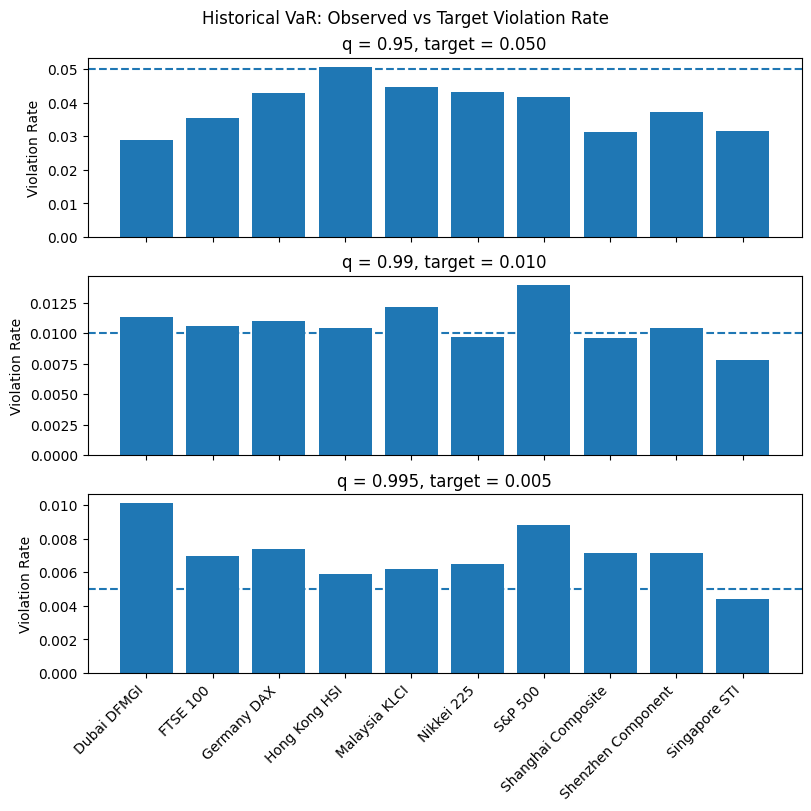

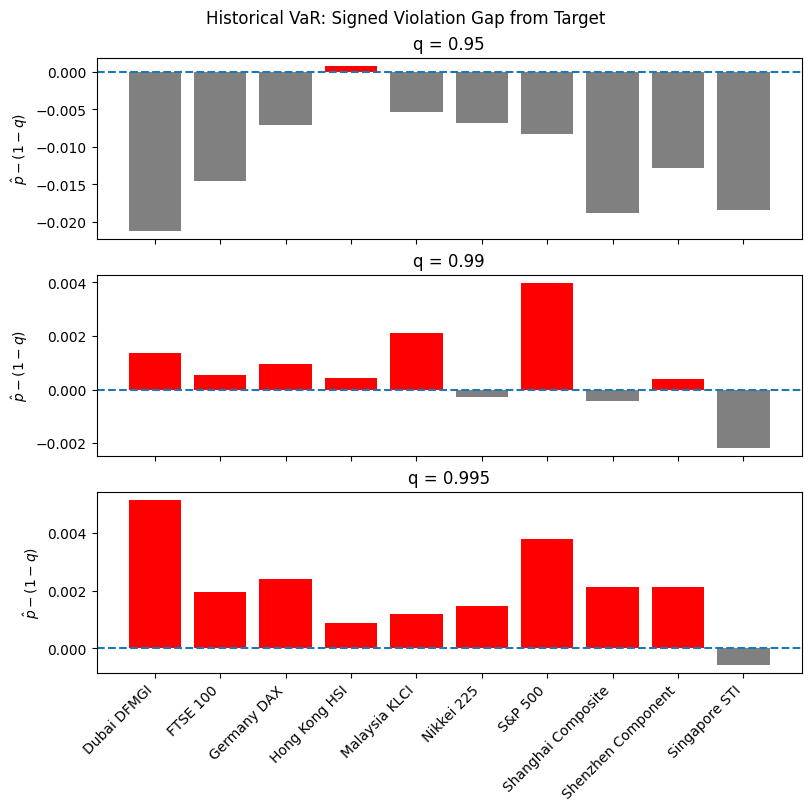

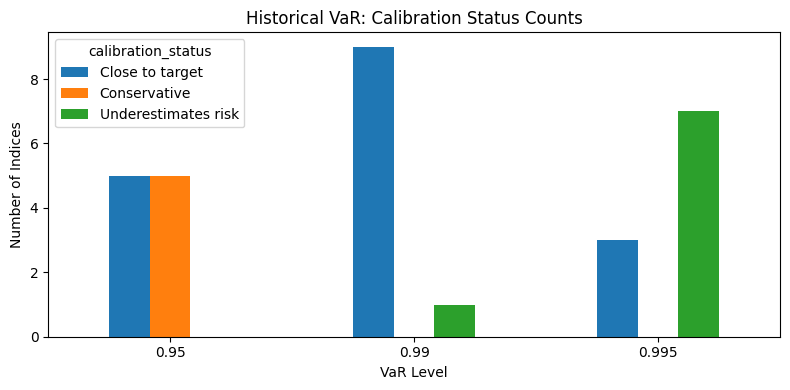

calibration_status,Close to target,Conservative,Underestimates risk
VaR Level,,,
0.950,5,5,0
0.990,9,0,1
0.995,3,0,7


In [58]:
# ============================================================
# Plots for Student-t VaR
# ============================================================

plot_observed_vs_target_violation_rate_stacked(student_t_var_summary_df)
plot_signed_violation_gap_stacked(student_t_var_summary_df)

student_t_calibration_count_table = plot_calibration_status_counts(student_t_var_summary_df)
student_t_calibration_count_table

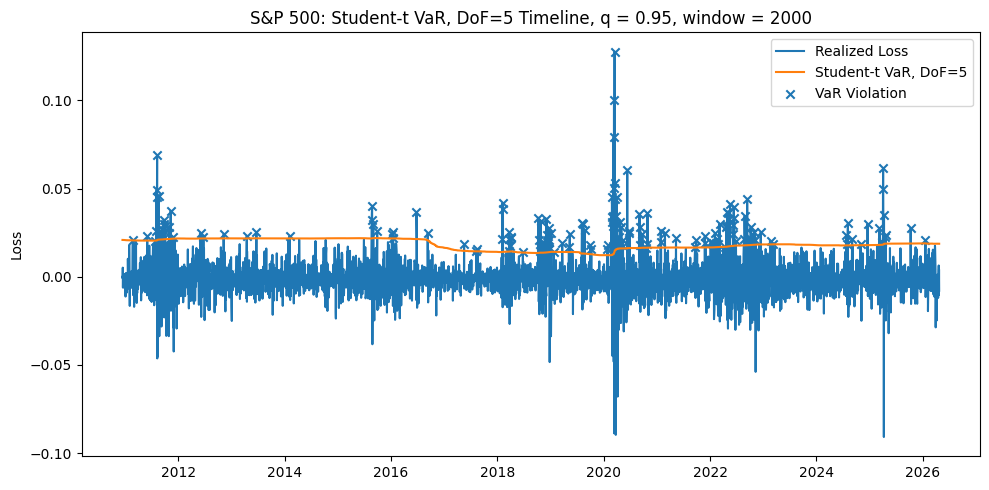

In [59]:
# ============================================================
# Student-t VaR Timeline Example
# ============================================================

plot_generic_var_timeline(
    forecasts_dict=student_t_var_forecasts_dict,
    index_name="S&P 500",
    window_length=WINDOW_LENGTH,
    q=0.95,
    var_column="student_t_var",
    model_label=f"Student-t VaR, DoF={STUDENT_T_DOF}",
    last_n=None,
)

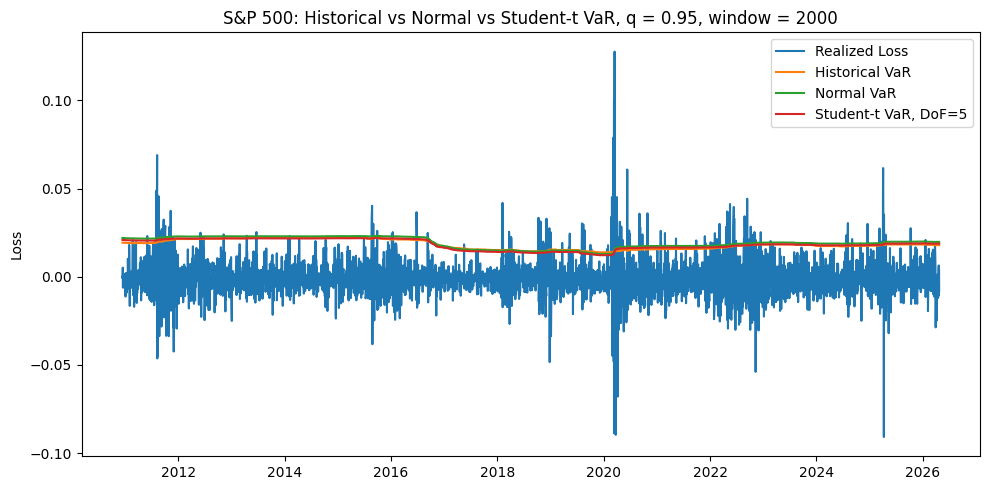

In [60]:
# ============================================================
# Optional: Historical VaR vs Normal VaR vs Student-t VaR
# ============================================================

def plot_three_var_comparison_timeline(
    historical_dict,
    normal_dict,
    student_t_dict,
    index_name,
    window_length,
    q,
    last_n=None,
):
    """
    Plot realized losses together with Historical VaR, Normal VaR,
    and Student-t VaR for direct comparison.
    """
    key = (index_name, window_length, q)

    if key not in historical_dict:
        raise KeyError(f"No Historical VaR data found for key: {key}")
    if key not in normal_dict:
        raise KeyError(f"No Normal VaR data found for key: {key}")
    if key not in student_t_dict:
        raise KeyError(f"No Student-t VaR data found for key: {key}")

    hist_df = historical_dict[key].copy()
    norm_df = normal_dict[key].copy()
    t_df = student_t_dict[key].copy()

    df = pd.concat(
        [
            hist_df[["realized_loss", "historical_var", "violation"]].rename(
                columns={"violation": "historical_violation"}
            ),
            norm_df[["normal_var", "violation"]].rename(
                columns={"violation": "normal_violation"}
            ),
            t_df[["student_t_var", "violation"]].rename(
                columns={"violation": "student_t_violation"}
            ),
        ],
        axis=1,
    )

    if last_n is not None:
        df = df.tail(last_n)

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["realized_loss"], label="Realized Loss")
    plt.plot(df.index, df["historical_var"], label="Historical VaR")
    plt.plot(df.index, df["normal_var"], label="Normal VaR")
    plt.plot(df.index, df["student_t_var"], label=f"Student-t VaR, DoF={STUDENT_T_DOF}")

    plt.ylabel("Loss")
    plt.title(
        f"{index_name}: Historical vs Normal vs Student-t VaR, "
        f"q = {q}, window = {window_length}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_three_var_comparison_timeline(
    historical_dict=historical_var_forecasts_dict,
    normal_dict=normal_var_forecasts_dict,
    student_t_dict=student_t_var_forecasts_dict,
    index_name="S&P 500",
    window_length=WINDOW_LENGTH,
    q=0.95,
    last_n=None,
)

## Student-$t$ VaR Results with a 2000-Day Window

The Student-$t$ VaR results show a clear improvement over the Normal VaR baseline, especially at higher confidence levels.

At the 95% VaR level, the result is similar to the earlier baseline pattern: 5 out of 10 indices are close to the target violation rate, while 5 are conservative. Thus, at the moderate 95% level, Student-$t$ VaR behaves reasonably, but does not differ much from the simpler baselines.

At the 99% VaR level, the improvement is substantial. Here, 9 out of 10 indices are close to the target violation rate, while only 1 index is classified as underestimating risk. This suggests that using a heavier-tailed Student-$t$ distribution with $\nu=5$ corrects much of the tail underestimation seen under Normal VaR.

At the 99.5% VaR level, however, the model still struggles. Only 3 out of 10 indices are close to the target violation rate, while 7 underestimate risk. This means that even with heavier tails, the fixed-$\nu$ Student-$t$ assumption is still not fully adequate for the most extreme tail events in this dataset.

Overall, Student-$t$ VaR with $\nu=5$ is a useful improvement over Normal VaR. It is still simple and computationally light, but it handles the 99% tail much better than the Gaussian model. However, its weakness at the 99.5% level suggests that a fixed distributional assumption may still be too rigid for extreme-loss modeling. This provides motivation for later notebooks on filtered historical simulation, GARCH-based VaR, EVT-based VaR, and other tail-aware methods.

---
## Summary Comparison of the Three Baseline VaR Methods

We now summarize the three baseline VaR methods — Historical VaR, Normal VaR, and Student-$t$ VaR — in a compact comparison table. The goal is not to reproduce every index-level detail again, but to provide a small cross-method summary for each confidence level.

For each VaR level, we compare the methods using the following summary measures:

1. the number of indices whose observed violation rate is `Close to target`;
2. the number of indices for which the model `Underestimates risk`;
3. the mean absolute deviation
   $$
   |\hat{p}-(1-q)|
   $$
   across indices.

These measures keep the summary small while still capturing the main calibration differences across the three baseline methods.

As a traditional concluding visual reference, we also plot the empirical historical loss distribution together with the three VaR thresholds produced by the three methods. This provides an intuitive picture of how Historical VaR, Normal VaR, and Student-$t$ VaR are positioned relative to the observed loss distribution and to one another.

In [61]:
# ============================================================
# Summary Comparison Table for the Three Baseline VaR Methods
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Build a compact comparison table
# ------------------------------------------------------------

def build_model_comparison_row(summary_df, model_name, q):
    df_q = summary_df[summary_df["VaR Level"] == q].copy()

    close_count = (df_q["calibration_status"] == "Close to target").sum()
    under_count = (df_q["calibration_status"] == "Underestimates risk").sum()
    mean_abs_dev = df_q["abs_deviation"].mean()

    return {
        "Model": model_name,
        "VaR Level": q,
        "Close to Target": int(close_count),
        "Underestimates Risk": int(under_count),
        "Mean Absolute Deviation": mean_abs_dev,
    }


comparison_rows = []

for q in VAR_LEVELS:
    comparison_rows.append(
        build_model_comparison_row(historical_var_summary_df, "Historical VaR", q)
    )
    comparison_rows.append(
        build_model_comparison_row(normal_var_summary_df, "Normal VaR", q)
    )
    comparison_rows.append(
        build_model_comparison_row(
            student_t_var_summary_df,
            f"Student-t VaR, DoF={STUDENT_T_DOF}",
            q,
        )
    )

baseline_var_comparison_df = pd.DataFrame(comparison_rows)

baseline_var_comparison_df

,Model,VaR Level,Close to Target,Underestimates Risk,Mean Absolute Deviation
0,Historical VaR,0.950,5,0,0.011398
1,Normal VaR,0.950,5,0,0.016249
2,"Student-t VaR, DoF=5",0.950,5,0,0.011409
3,Historical VaR,0.990,7,0,0.001700
4,Normal VaR,0.990,2,8,0.004406
5,"Student-t VaR, DoF=5",0.990,9,1,0.001264
6,Historical VaR,0.995,5,0,0.001170
7,Normal VaR,0.995,0,10,0.006122
8,"Student-t VaR, DoF=5",0.995,3,7,0.002162


In [62]:
# ============================================================
# Save Summary Comparison Table
# ============================================================

baseline_var_comparison_path = os.path.join(
    RESULTS_DIR,
    f"01_baseline_var_comparison_window_{WINDOW_LENGTH}.csv"
)

baseline_var_comparison_df.to_csv(baseline_var_comparison_path, index=False)

print(f"Saved baseline comparison table to: {baseline_var_comparison_path}")

Saved baseline comparison table to: results/01_baseline_var_comparison_window_2000.csv


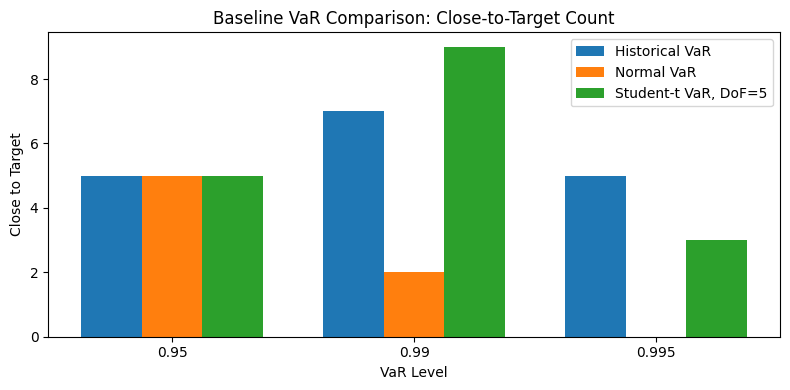

In [65]:
# ============================================================
# Plot A: Close-to-Target Count by Model and VaR Level
# ============================================================

def plot_baseline_comparison_counts(comparison_df, metric_col, title):
    q_order = sorted(comparison_df["VaR Level"].unique())
    model_order = comparison_df["Model"].unique().tolist()

    x = np.arange(len(q_order))
    width = 0.25

    plt.figure(figsize=(8, 4))

    for i, model in enumerate(model_order):
        df_model = (
            comparison_df[comparison_df["Model"] == model]
            .set_index("VaR Level")
            .reindex(q_order)
            .reset_index()
        )

        plt.bar(
            x + (i - 1) * width,
            df_model[metric_col].values,
            width=width,
            label=model,
        )

    plt.xticks(x, q_order)
    plt.xlabel("VaR Level")
    plt.ylabel(metric_col)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_baseline_comparison_counts(
    baseline_var_comparison_df,
    metric_col="Close to Target",
    title="Baseline VaR Comparison: Close-to-Target Count",
)

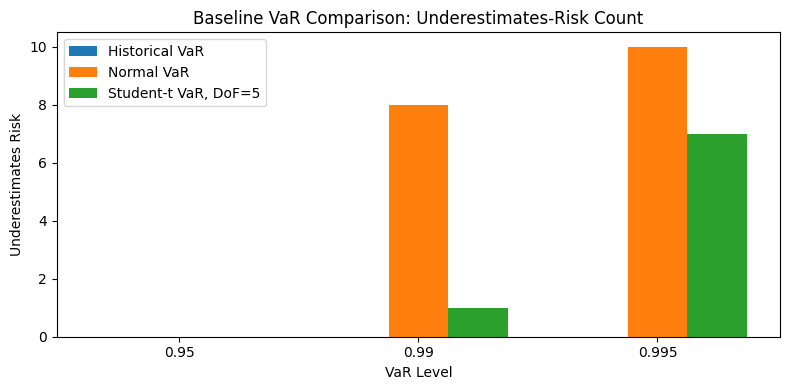

In [66]:
# ============================================================
# Plot B: Underestimates-Risk Count by Model and VaR Level
# ============================================================

plot_baseline_comparison_counts(
    baseline_var_comparison_df,
    metric_col="Underestimates Risk",
    title="Baseline VaR Comparison: Underestimates-Risk Count",
)

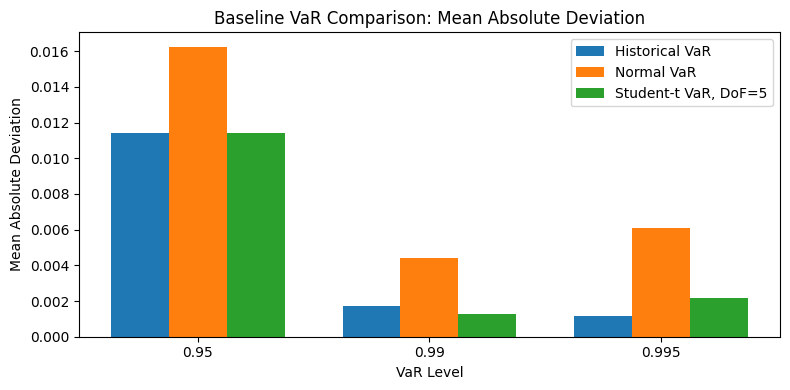

In [67]:
# ============================================================
# Plot C: Mean Absolute Deviation by Model and VaR Level
# ============================================================

def plot_baseline_mean_abs_deviation(comparison_df):
    q_order = sorted(comparison_df["VaR Level"].unique())
    model_order = comparison_df["Model"].unique().tolist()

    x = np.arange(len(q_order))
    width = 0.25

    plt.figure(figsize=(8, 4))

    for i, model in enumerate(model_order):
        df_model = (
            comparison_df[comparison_df["Model"] == model]
            .set_index("VaR Level")
            .reindex(q_order)
            .reset_index()
        )

        plt.bar(
            x + (i - 1) * width,
            df_model["Mean Absolute Deviation"].values,
            width=width,
            label=model,
        )

    plt.xticks(x, q_order)
    plt.xlabel("VaR Level")
    plt.ylabel("Mean Absolute Deviation")
    plt.title("Baseline VaR Comparison: Mean Absolute Deviation")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_baseline_mean_abs_deviation(baseline_var_comparison_df)

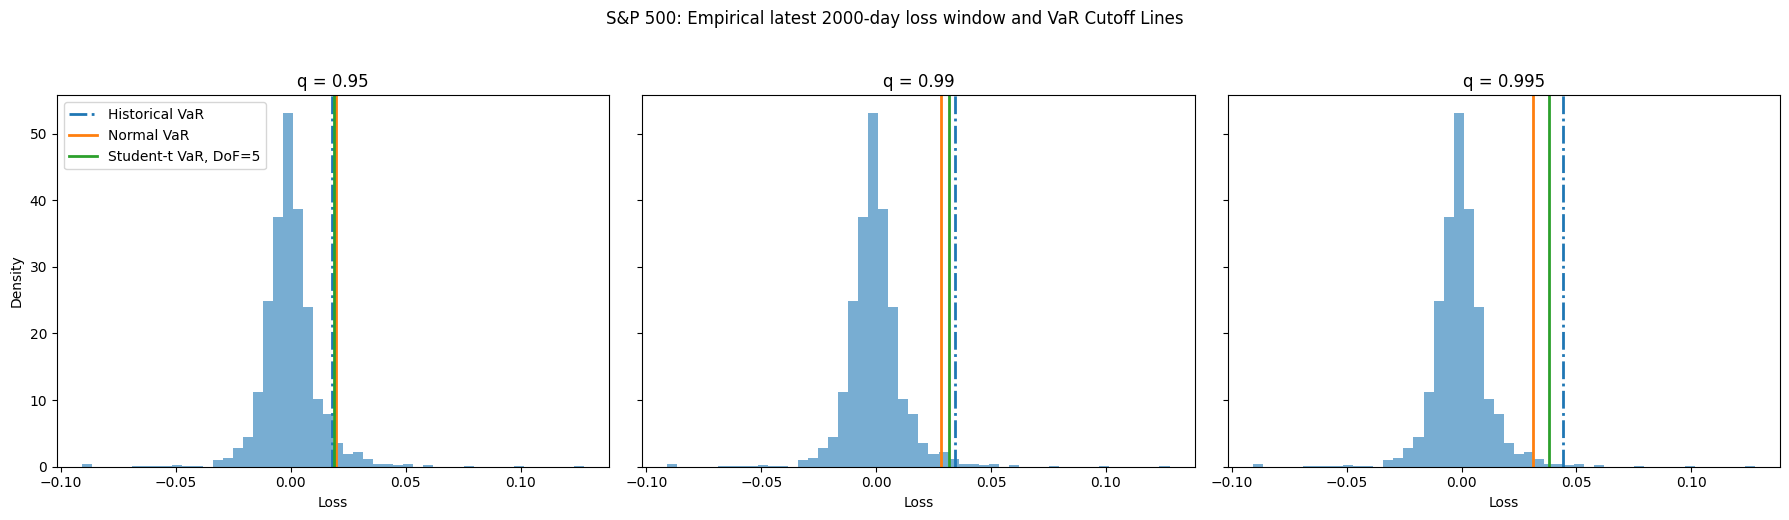

In [90]:
# ============================================================
# Distribution Plot with the Three VaR Cutoff Lines
# ============================================================

def get_var_cutoff_for_index(summary_forecasts_dict, key, var_col):
    df = summary_forecasts_dict[key].copy()
    # use the latest available forecast as the displayed VaR cutoff
    return df[var_col].dropna().iloc[-1]


def plot_empirical_distribution_with_var_lines(
    index_name="S&P 500",
    window_length=WINDOW_LENGTH,
    sample_type="latest_window",   # "latest_window" or "full_sample"
):
    """
    Plot three horizontally juxtaposed panels across the three VaR levels.
    Each panel shows the empirical loss distribution and the three VaR cutoffs:
    Historical VaR, Normal VaR, and Student-t VaR.

    sample_type:
        - "latest_window": use the most recent rolling window of losses
        - "full_sample":   use the full available loss history
    """
    loss_series = losses[index_name].dropna().astype(float)

    if sample_type == "latest_window":
        plot_losses = loss_series.iloc[-window_length:]
        sample_label = f"latest {window_length}-day loss window"
    elif sample_type == "full_sample":
        plot_losses = loss_series.copy()
        sample_label = "full loss sample"
    else:
        raise ValueError("sample_type must be 'latest_window' or 'full_sample'.")

    fig, axes = plt.subplots(1, len(VAR_LEVELS), figsize=(18, 5), sharey=True)

    if len(VAR_LEVELS) == 1:
        axes = [axes]

    for ax, q in zip(axes, VAR_LEVELS):
        key = (index_name, window_length, q)

        hist_cutoff = get_var_cutoff_for_index(
            historical_var_forecasts_dict, key, "historical_var"
        )
        norm_cutoff = get_var_cutoff_for_index(
            normal_var_forecasts_dict, key, "normal_var"
        )
        t_cutoff = get_var_cutoff_for_index(
            student_t_var_forecasts_dict, key, "student_t_var"
        )

        ax.hist(plot_losses, bins=50, density=True, alpha=0.6)

        # solid cutoff lines with different colors
        ax.axvline(hist_cutoff, color="tab:blue", linewidth=2, linestyle="-.", label="Historical VaR")
        ax.axvline(norm_cutoff, color="tab:orange", linewidth=2, label="Normal VaR")
        ax.axvline(
            t_cutoff,
            color="tab:green",
            linewidth=2,
            label=f"Student-t VaR, DoF={STUDENT_T_DOF}",
        )

        ax.set_title(f"q = {q}")
        ax.set_xlabel("Loss")

    axes[0].set_ylabel("Density")
    axes[0].legend(loc="upper left")

    fig.suptitle(
        f"{index_name}: Empirical {sample_label} and VaR Cutoff Lines",
        y=1.03,
    )

    plt.tight_layout()
    plt.show()


# Example: most recent rolling window distribution
plot_empirical_distribution_with_var_lines(
    index_name="S&P 500",
    window_length=WINDOW_LENGTH,
    sample_type="latest_window",
)

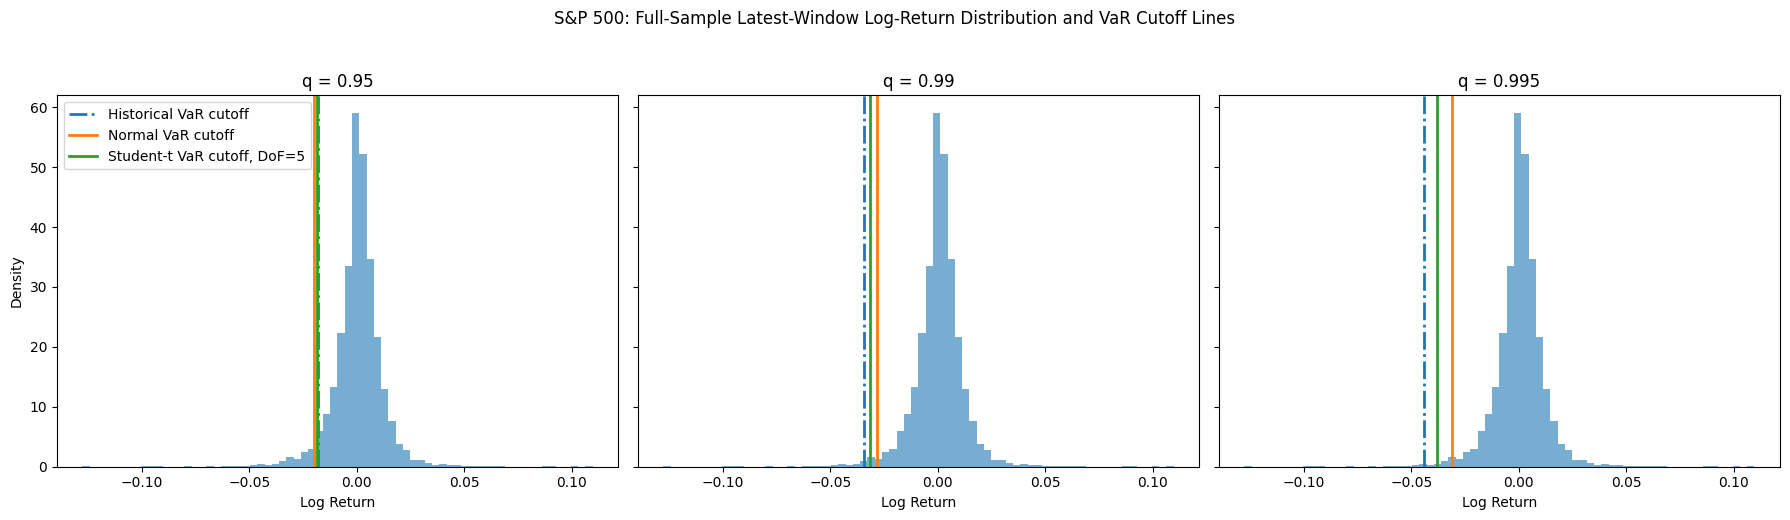

In [89]:
# ============================================================
# Full-Sample Return Distribution with Colored VaR Cutoff Lines
# ============================================================

def get_latest_var_cutoff_in_loss_units(forecasts_dict, key, var_col):
    """
    Extract the latest available VaR forecast in loss units.
    """
    df = forecasts_dict[key].copy()
    return df[var_col].dropna().iloc[-1]


def plot_full_sample_return_distribution_with_var_lines(
    index_name="S&P 500",
    window_length=WINDOW_LENGTH,
):
    """
    Plot the full-sample log-return distribution for one index, with
    three horizontally arranged panels across the three VaR levels.

    Since the VaR models were computed on losses L_t = -r_t, the cutoff
    lines are converted back into return units by negation.
    """
    return_series = returns[index_name].dropna().astype(float)

    fig, axes = plt.subplots(1, len(VAR_LEVELS), figsize=(18, 5), sharey=True)

    if len(VAR_LEVELS) == 1:
        axes = [axes]

    var_colors = {
        "Historical VaR cutoff": "tab:blue",
        "Normal VaR cutoff": "tab:orange",
        f"Student-t VaR cutoff, DoF={STUDENT_T_DOF}": "tab:green",
    }

    for ax, q in zip(axes, VAR_LEVELS):
        key = (index_name, window_length, q)

        hist_return_var = -get_latest_var_cutoff_in_loss_units(
            historical_var_forecasts_dict, key, "historical_var"
        )
        norm_return_var = -get_latest_var_cutoff_in_loss_units(
            normal_var_forecasts_dict, key, "normal_var"
        )
        t_return_var = -get_latest_var_cutoff_in_loss_units(
            student_t_var_forecasts_dict, key, "student_t_var"
        )

        ax.hist(return_series, bins=70, density=True, alpha=0.6)

        ax.axvline(
            hist_return_var,
            color=var_colors["Historical VaR cutoff"],
            linewidth=2,
            linestyle="-.",
            label="Historical VaR cutoff",
        )
        ax.axvline(
            norm_return_var,
            color=var_colors["Normal VaR cutoff"],
            linewidth=2,
            label="Normal VaR cutoff",
        )
        ax.axvline(
            t_return_var,
            color=var_colors[f"Student-t VaR cutoff, DoF={STUDENT_T_DOF}"],
            linewidth=2,
            label=f"Student-t VaR cutoff, DoF={STUDENT_T_DOF}",
        )

        ax.set_title(f"q = {q}")
        ax.set_xlabel("Log Return")

    axes[0].set_ylabel("Density")
    axes[0].legend()

    fig.suptitle(
        f"{index_name}: Full-Sample Latest-Window Log-Return Distribution and VaR Cutoff Lines",
        y=1.03,
    )

    plt.tight_layout()
    plt.show()


plot_full_sample_return_distribution_with_var_lines(
    index_name="S&P 500",
    window_length=WINDOW_LENGTH,
)

## Using 95% VaR for Exposure Control - Demonstration

We now illustrate how a VaR estimate can be used as a simple exposure-control rule. This is not a return-prediction strategy. The VaR model does not say whether the index will go up or down tomorrow. It only estimates the size of a one-day loss that should be exceeded with probability approximately $5\%$.

For this illustration, we use only the 95% VaR level. Suppose the portfolio manager sets a one-day risk budget $B$, expressed as a fraction of current portfolio value. For example, $B=0.01$ means that the portfolio is allowed to carry approximately 1% one-day VaR risk.

Let

$$
\widehat{\operatorname{VaR}}_{0.95,t}
$$

be the estimated one-day 95% VaR in return-loss units. We choose the exposure multiplier

$$
w_t
=
\min\left(1,\frac{B}{\widehat{\operatorname{VaR}}_{0.95,t}}\right).
$$

Thus, when estimated VaR is below the risk budget, the strategy keeps full exposure. When estimated VaR is above the risk budget, the strategy scales exposure down.

The next-day risk-scaled return is then

$$
R^{\mathrm{scaled}}_{t+1}
=
w_t R_{t+1}.
$$

For comparison, the unscaled buy-and-hold proxy is simply

$$
R^{\mathrm{buyhold}}_{t+1}
=
R_{t+1}.
$$

The purpose of this exercise is to show how VaR can be connected to practical portfolio exposure control. The indices are treated as tradable proxies only for demonstration. This is not a trading recommendation, and it ignores transaction costs, slippage, tracking instruments, leverage constraints, taxes, and implementation details.

In [81]:
# ============================================================
# VaR-Based Exposure Control Backtest: S&P 500
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

INDEX_NAME = "S&P 500"
Q_TEST = 0.95
RISK_BUDGET = 0.01      # daily VaR budget: 1% of portfolio value
INITIAL_CAPITAL = 1.0   # normalized equity curve


# ------------------------------------------------------------
# 2. Helper: Build VaR-Scaled Strategy
# ------------------------------------------------------------

def run_var_exposure_backtest(
    returns,
    var_forecasts_dict,
    index_name,
    window_length,
    q,
    var_column,
    model_label,
    risk_budget=0.01,
    initial_capital=1.0,
):
    """
    Backtest a simple VaR-based exposure-control rule.

    Exposure rule:
        w_t = min(1, risk_budget / VaR_t)

    Strategy return:
        R_scaled,t = w_t * R_t

    Parameters
    ----------
    returns : pd.DataFrame
        Log-return dataframe.
    var_forecasts_dict : dict
        Dictionary containing realized losses and VaR forecasts.
    index_name : str
        Name of the index to backtest.
    window_length : int
        Rolling VaR window length.
    q : float
        VaR confidence level.
    var_column : str
        Column name containing the VaR forecast.
    model_label : str
        Label for the VaR model.
    risk_budget : float
        Maximum one-day VaR risk budget in return units.
    initial_capital : float
        Starting value of normalized equity curve.

    Returns
    -------
    pd.DataFrame
        Backtest dataframe.
    """
    key = (index_name, window_length, q)

    if key not in var_forecasts_dict:
        raise KeyError(f"No VaR forecast found for key: {key}")

    var_df = var_forecasts_dict[key].copy()

    index_returns = returns[index_name].dropna().astype(float)

    common_index = var_df.index.intersection(index_returns.index)

    bt = pd.DataFrame(index=common_index)
    bt["return"] = index_returns.loc[common_index]
    bt["realized_loss"] = -bt["return"]
    bt["var"] = var_df.loc[common_index, var_column]

    # Avoid division issues.
    bt = bt.replace([np.inf, -np.inf], np.nan).dropna()

    # Exposure rule.
    bt["exposure"] = risk_budget / bt["var"]
    bt["exposure"] = bt["exposure"].clip(lower=0, upper=1)

    # Strategy return.
    bt["scaled_return"] = bt["exposure"] * bt["return"]

    # Buy-and-hold benchmark.
    bt["buyhold_return"] = bt["return"]

    # Equity curves.
    bt["scaled_equity"] = initial_capital * np.exp(bt["scaled_return"].cumsum())
    bt["buyhold_equity"] = initial_capital * np.exp(bt["buyhold_return"].cumsum())

    # VaR violations based on realized loss and forecasted VaR.
    bt["var_violation"] = (bt["realized_loss"] > bt["var"]).astype(int)

    bt["model"] = model_label
    bt["risk_budget"] = risk_budget
    bt["var_level"] = q

    return bt

In [82]:
# ============================================================
# 3. Run VaR Exposure Backtests for the Three Baseline Models
# ============================================================

sp500_historical_bt = run_var_exposure_backtest(
    returns=returns,
    var_forecasts_dict=historical_var_forecasts_dict,
    index_name=INDEX_NAME,
    window_length=WINDOW_LENGTH,
    q=Q_TEST,
    var_column="historical_var",
    model_label="Historical VaR",
    risk_budget=RISK_BUDGET,
    initial_capital=INITIAL_CAPITAL,
)

sp500_normal_bt = run_var_exposure_backtest(
    returns=returns,
    var_forecasts_dict=normal_var_forecasts_dict,
    index_name=INDEX_NAME,
    window_length=WINDOW_LENGTH,
    q=Q_TEST,
    var_column="normal_var",
    model_label="Normal VaR",
    risk_budget=RISK_BUDGET,
    initial_capital=INITIAL_CAPITAL,
)

sp500_student_t_bt = run_var_exposure_backtest(
    returns=returns,
    var_forecasts_dict=student_t_var_forecasts_dict,
    index_name=INDEX_NAME,
    window_length=WINDOW_LENGTH,
    q=Q_TEST,
    var_column="student_t_var",
    model_label=f"Student-t VaR, DoF={STUDENT_T_DOF}",
    risk_budget=RISK_BUDGET,
    initial_capital=INITIAL_CAPITAL,
)

sp500_historical_bt.head()

,return,realized_loss,var,exposure,scaled_return,buyhold_return,scaled_equity,buyhold_equity,var_violation,model,risk_budget,var_level
Date,,,,,,,,,,,,
2010-12-13,0.000048,-0.000048,0.019303,0.518053,0.000025,0.000048,1.000025,1.000048,0,Historical VaR,0.01,0.95
2010-12-14,0.000911,-0.000911,0.019303,0.518053,0.000472,0.000911,1.000497,1.000959,0,Historical VaR,0.01,0.95
2010-12-15,-0.005136,0.005136,0.019303,0.518053,-0.002661,-0.005136,0.997839,0.995832,0,Historical VaR,0.01,0.95
2010-12-16,0.006166,-0.006166,0.019303,0.518053,0.003194,0.006166,1.001031,1.001991,0,Historical VaR,0.01,0.95
2010-12-17,0.000836,-0.000836,0.019303,0.518053,0.000433,0.000836,1.001465,1.002830,0,Historical VaR,0.01,0.95


In [83]:
# ============================================================
# 4. Backtest Performance Summary
# ============================================================

def max_drawdown(equity):
    """
    Compute maximum drawdown from an equity curve.
    """
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    return drawdown.min()


def summarize_var_exposure_backtest(bt, strategy_col="scaled_return"):
    """
    Summarize VaR-scaled strategy performance.
    """
    equity_col = "scaled_equity" if strategy_col == "scaled_return" else "buyhold_equity"

    ann_factor = 252

    mean_daily = bt[strategy_col].mean()
    vol_daily = bt[strategy_col].std(ddof=1)

    ann_return = mean_daily * ann_factor
    ann_vol = vol_daily * np.sqrt(ann_factor)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    return {
        "Model": bt["model"].iloc[0],
        "Risk Budget": bt["risk_budget"].iloc[0],
        "VaR Level": bt["var_level"].iloc[0],
        "Num Days": len(bt),
        "Final Equity": bt[equity_col].iloc[-1],
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown(bt[equity_col]),
        "Average Exposure": bt["exposure"].mean(),
        "Minimum Exposure": bt["exposure"].min(),
        "VaR Violation Rate": bt["var_violation"].mean(),
    }


sp500_var_strategy_summary = pd.DataFrame([
    summarize_var_exposure_backtest(sp500_historical_bt),
    summarize_var_exposure_backtest(sp500_normal_bt),
    summarize_var_exposure_backtest(sp500_student_t_bt),
])

# Buy-and-hold summary, using one of the aligned backtest frames.
buyhold_summary = summarize_var_exposure_backtest(
    sp500_historical_bt.assign(model="Buy and Hold"),
    strategy_col="buyhold_return",
)

sp500_var_strategy_summary = pd.concat(
    [
        pd.DataFrame([buyhold_summary]),
        sp500_var_strategy_summary,
    ],
    ignore_index=True,
)

sp500_var_strategy_summary

,Model,Risk Budget,VaR Level,Num Days,Final Equity,Annualized Return,Annualized Volatility,Sharpe,Max Drawdown,Average Exposure,Minimum Exposure,VaR Violation Rate
0,Buy and Hold,0.01,0.95,3864,5.776427,0.114377,0.172438,0.663295,-0.339250,0.558017,0.447539,0.042702
1,Historical VaR,0.01,0.95,3864,2.611393,0.062601,0.102062,0.613365,-0.252909,0.558017,0.447539,0.042702
2,Normal VaR,0.01,0.95,3864,2.437452,0.058106,0.097207,0.597754,-0.256156,0.532800,0.432143,0.037526
3,"Student-t VaR, DoF=5",0.01,0.95,3864,2.559284,0.061287,0.102551,0.597621,-0.268250,0.562082,0.455506,0.041667


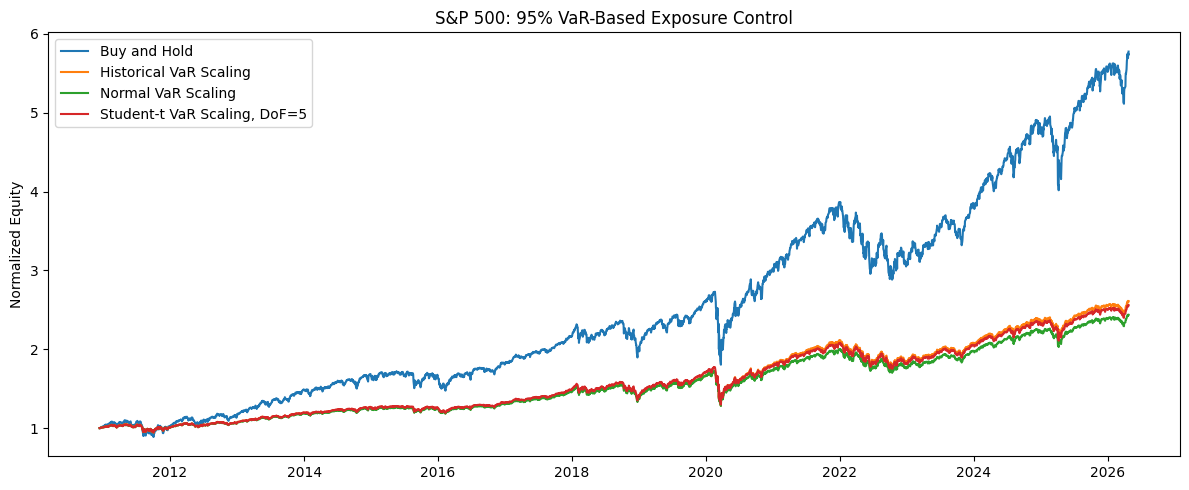

In [85]:
# ============================================================
# 5. Plot Equity Curves
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    sp500_historical_bt.index,
    sp500_historical_bt["buyhold_equity"],
    label="Buy and Hold",
)

plt.plot(
    sp500_historical_bt.index,
    sp500_historical_bt["scaled_equity"],
    label="Historical VaR Scaling",
)

plt.plot(
    sp500_normal_bt.index,
    sp500_normal_bt["scaled_equity"],
    label="Normal VaR Scaling",
)

plt.plot(
    sp500_student_t_bt.index,
    sp500_student_t_bt["scaled_equity"],
    label=f"Student-t VaR Scaling, DoF={STUDENT_T_DOF}",
)

plt.title(f"{INDEX_NAME}: 95% VaR-Based Exposure Control")
plt.ylabel("Normalized Equity")
plt.legend()
plt.tight_layout()
plt.show()

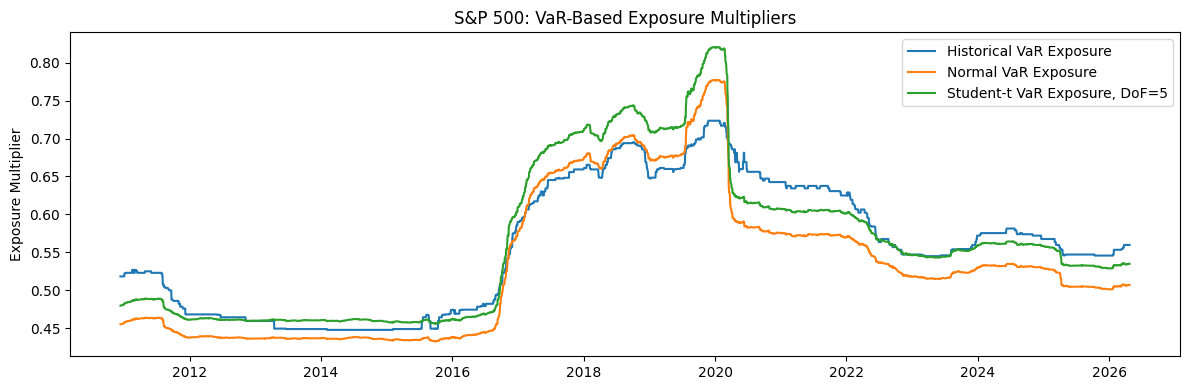

In [86]:
# ============================================================
# 6. Plot Exposure Paths
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(
    sp500_historical_bt.index,
    sp500_historical_bt["exposure"],
    label="Historical VaR Exposure",
)

plt.plot(
    sp500_normal_bt.index,
    sp500_normal_bt["exposure"],
    label="Normal VaR Exposure",
)

plt.plot(
    sp500_student_t_bt.index,
    sp500_student_t_bt["exposure"],
    label=f"Student-t VaR Exposure, DoF={STUDENT_T_DOF}",
)

plt.title(f"{INDEX_NAME}: VaR-Based Exposure Multipliers")
plt.ylabel("Exposure Multiplier")
plt.legend()
plt.tight_layout()
plt.show()

The previous two plots illustrate how 95% VaR can be used as a risk-control input rather than as a return-forecasting signal.

The exposure rule sets a daily risk budget and scales the index exposure according to the estimated VaR. Although the confidence level and window length are fixed, the VaR estimate itself is rolling. At each date, the VaR value is recomputed from the most recent 2000 observations. Therefore, when the rolling VaR estimate rises, the exposure multiplier falls; when the rolling VaR estimate declines, the exposure multiplier rises, up to a maximum of full exposure.

The first plot compares the resulting equity curves against buy-and-hold. The VaR-scaled strategies grow more slowly because they usually hold less than full exposure. This is expected: the purpose of the rule is not to maximize return, but to keep estimated one-day downside risk within a fixed budget.

The second plot shows the exposure multipliers generated by the three VaR models. Differences across the exposure paths come from differences in the estimated VaR levels. A higher VaR estimate leads to lower exposure, while a lower VaR estimate permits higher exposure. The sharp exposure changes around stress periods reflect the VaR models reacting to changes in realized loss behavior.

Overall, these plots show the practical role of VaR in portfolio management: it can be used as a dynamic sizing mechanism that links estimated downside risk to portfolio exposure.

In [87]:
# ============================================================
# 7. Save VaR Exposure-Control Backtest Results
# ============================================================

sp500_historical_bt.to_csv(
    os.path.join(RESULTS_DIR, "01_sp500_historical_var_exposure_backtest.csv")
)

sp500_normal_bt.to_csv(
    os.path.join(RESULTS_DIR, "01_sp500_normal_var_exposure_backtest.csv")
)

sp500_student_t_bt.to_csv(
    os.path.join(RESULTS_DIR, "01_sp500_student_t_var_exposure_backtest.csv")
)

sp500_var_strategy_summary.to_csv(
    os.path.join(RESULTS_DIR, "01_sp500_var_exposure_backtest_summary.csv"),
    index=False,
)

print("Saved S&P 500 VaR exposure-control backtest results.")

Saved S&P 500 VaR exposure-control backtest results.


## References

1. Jorion, P. (2007). *Value at Risk: The New Benchmark for Managing Financial Risk* (3rd ed.). McGraw-Hill. https://books.google.com/books?id=nnblKhI7KP8C